In [ ]:
import sys; sys.path.insert(0, '../Sparse_Cholesky')

# FONKNORIS Foundation Modeling with CHONKNORIS

Authored by Aras Bacho

In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
# import pyKoLesky.ordering
# import pyKoLesky.cholesky
from cholesky import *
from ordering import *

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

torch.set_default_dtype(torch.float64)
dtype = torch.float64

# General Parameters
N = 32  # Number of grid points
L = 1.0  # Length of the domain [0, 1]
rho = 1000  # Sparsity factor defined by ln(N/epsilon)
x = torch.linspace(0, L, N + 1)[:-1]  # Equidistant grid points
x_ten = x.unsqueeze(1)
dx = x[1] - x[0]  # Grid spacing

# Training data
num_realizations = 1000  # Number of realizations
num_realizations_darcy = 2000  # Number of realizations
num_folds = 5  # For cross-validation
lambda_reg_1 = 0.01  # Regularizer for the Newton-Iteration for Nonlinear Elliptic
lambda_reg_2 = 0.01  # Regularizer for the Newton-Iteration for Burgers
lambda_reg_3 = 0.01  # Regularizer for the Newton-Iteration for Darcy
lambda_reg_4 = 0.01  # Regularizer for the Newton-Iteration for Sine-Gordon


# Sparsity pattern
Perm, lengths = maximin(x_ten)  # Calculating MaxMin Ordering
sparsity = sparsity_pattern(x_ten[Perm], lengths, rho)  # Calculating the sparsity pattern
nonzeros_indices = non_zeros(N, sparsity)  # Calculating the non zero indices


# Gaussian Process class with learnable nugget
class GaussianProcess(nn.Module):
    def __init__(self, length_scale=1.0, nugget_init=1e-6, nu=3 / 2):
        super(GaussianProcess, self).__init__()
        self.length_scale = nn.Parameter(torch.rand(3 * N) * length_scale)
        # self.length_scale = nn.Parameter(torch.ones(1) * length_scale)
        # self.nugget = nn.Parameter(torch.tensor(nugget_init))
        self.nugget = torch.tensor(nugget_init)
        self.nu = nu

    def matern_kernel(self, X1, X2):
        # Compute pairwise Euclidean distance between points in scaled X1 and X2
        X1_scaled = X1 * self.length_scale
        X2_scaled = X2 * self.length_scale
        pairwise_dists = torch.cdist(X1_scaled, X2_scaled, p=2)

        if self.nu == 3 / 2:
            scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
            K = (1 + scale) * torch.exp(-scale)
        else:
            raise ValueError("Only nu=3/2 is supported.")
        return K
    
    def gaussian_kernel(self, X1, X2):
        # Scale the inputs
        X1_scaled = X1 / self.length_scale
        X2_scaled = X2 / self.length_scale
    
        # Compute pairwise squared Euclidean distances
        pairwise_dists_sq = torch.cdist(X1_scaled, X2_scaled, p=2) ** 2
    
        # Compute the RBF kernel
        K = torch.exp(-0.5 * pairwise_dists_sq)
    
        return K

    def fit(self, X_train, y_train):
        # Kernel matrices with learnable nugget
        K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
        
        # Solve via Cholesky Decomposition
        # L = torch.linalg.cholesky(K_train)
        # b = torch.linalg.solve_triangular(L, y_train, lower=True)
        # Solve L^T x = b
        # alpha_train = torch.linalg.solve_triangular(L.t(), b, lower=False)
    
        alpha_train = torch.linalg.solve(K_train, y_train)
        self.alpha_train = alpha_train
        self.X_train = X_train

    def forward(self, X_val):
        K_val_train = self.matern_kernel(X_val, self.X_train)
        y_pred_val = K_val_train @ self.alpha_train
        return y_pred_val
    
    #  def fit(self, X_train, y_train):
    #     # Kernel matrices with learnable nugget
    #     K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
    #     
    #     # Solve via Cholesky Decomposition
    #     # L = torch.linalg.cholesky(K_train)
    #     # b = torch.linalg.solve_triangular(L, y_train, lower=True)
    #     # Solve L^T x = b
    #     # alpha_train = torch.linalg.solve_triangular(L.t(), b, lower=False)
    # 
    #     alpha_train = torch.linalg.solve(K_train, y_train)
    #     self.alpha_train = alpha_train
    #     self.X_train = X_train
    # 
    # def forward(self, X_val):
    #     K_val_train = self.matern_kernel(X_val, self.X_train)
    #     y_pred_val = K_val_train @ self.alpha_train
    #     return y_pred_val

    # def forward(self, X_train, y_train, X_val):
    #     # Kernel matrices with learnable nugget
    #     K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
    #     # L = torch.linalg.cholesky(K_train)
    #     # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
    #     alpha_train = torch.linalg.solve(K_train, y_train)
    #
    #     K_val_train = self.matern_kernel(X_val, X_train)
    #     y_pred_val = K_val_train @ alpha_train
    #     return y_pred_val
    

# Generate the covariance matrix using the Matérn kernel
def generate_covariance_matrix(kernel_func, x, length_scale):
    return kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)


# Generate f and u based on GP(0, K)
def generate_dataset_from_gp(num_realizations, m, kernel_func, length_scale, x):
    K = kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)
    K = K + 1e-3 * torch.eye(K.shape[0])
    L = torch.linalg.cholesky(K)
    f_realizations = torch.randn(num_realizations, m)
    u_realizations = torch.randn(num_realizations, m)
    a_realizations = torch.randn(num_realizations, m)

    f_realizations = (L @ f_realizations.T).T
    u_realizations = (L @ u_realizations.T).T
    a_realizations = (L @ a_realizations.T).T
    # a_realizations = torch.exp(a_realizationstions)

    # mean = torch.zeros(N)
    # f_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    # u_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    return f_realizations, u_realizations, a_realizations


# Train step
def train_step(model, X, y, optimizer, scheduler):
    optimizer.zero_grad()
    loss_value = cross_validation_loss(model, X, y, num_folds)
    loss_value.backward()
    optimizer.step()
    scheduler.step()
    return loss_value

# def train_step(model, X, y, optimizer, scheduler, num_epochs=100, val_split=0.2):
#     # 1) Split into train/validation once
#     N = len(X)
#     split_idx = int((1 - val_split) * N)
#     indices = torch.randperm(N)
#     train_idx = indices[:split_idx]
#     val_idx   = indices[split_idx:]
#     
#     X_train, y_train = X[train_idx], y[train_idx]
#     X_val, y_val = X[val_idx], y[val_idx]
#     
#     for epoch in range(num_epochs):
#         # 2) Normal training step (no cross-validation inside!)
#         optimizer.zero_grad()
#         
#         # Fit model on full training data
#         model.fit(X_train, y_train)
#         
#         # Evaluate predictions on the same training data
#         y_pred_train = model(X_train)
#         train_loss = torch.mean(torch.norm(y_train - y_pred_train, dim=1) /
#                                 torch.norm(y_train, dim=1))
#         
#         # Backprop (if model.fit does not handle it internally).
#         # If you have a custom GP with learnable parameters, do something like:
#         # train_loss.backward()
#         # optimizer.step()
#         
#         # scheduler.step()
#         
#         # 3) Evaluate on validation data occasionally
#         if epoch % 5 == 0:
#             y_pred_val = model(X_val)
#             val_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) /
#                                   torch.norm(y_val, dim=1))
#             print(f"Epoch {epoch} | Train Loss {train_loss.item():.4f} | Val Loss {val_loss.item():.4f}")



def periodic_kernel(X1, X2, length_scale=1, period=1):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    sine_term = torch.sin(torch.pi * pairwise_dists / period)
    K = torch.exp(-2 * sine_term ** 2 / length_scale ** 2)
    return K

  
# Define the kernel function
def matern_kernel(X1, X2, length_scale):
    pairwise_dists = torch.cdist(X1 * length_scale, X2 * length_scale, p=2)
    scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
    K = (1 + scale) * torch.exp(-scale)
    return K


def gaussian_kernel(X1, X2, length_scale):
        # Scale the inputs
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
    
        # Compute pairwise squared Euclidean distances
        pairwise_dists_sq = torch.cdist(X1_scaled, X2_scaled, p=2) ** 2
    
        # Compute the RBF kernel
        K = torch.exp(-0.5 * pairwise_dists_sq)
    
        return K

# Periodic Laplacian matrix (finite difference approximation)
def laplacian_matrix(N, dx):
    main_diag = -2 * torch.ones(N)
    off_diag = torch.ones(N - 1)
    A = torch.diag(main_diag) + torch.diag(off_diag, 1) + torch.diag(off_diag, -1)
    A[0, -1] = 1
    A[-1, 0] = 1
    A /= dx ** 2
    return A


# Dirichlet Laplacian matrix (finite difference approximation)
def laplacian_matrix_dir(m, dx):
    main_diag = -2 * torch.ones(m)
    off_diag = torch.ones(m)
    A = torch.diag(main_diag) + torch.diag(off_diag, 1) + torch.diag(off_diag, -1)
    A /= dx ** 2
    return A


# Laplacian matrix for the grid
A_laplace = laplacian_matrix(N, dx)


# Invert matrix using Cholesky decomposition
def cholesky_inverse(A):
    L = torch.linalg.cholesky(A + 1e-8 * torch.eye(len(A)), upper=False)
    L_inv = torch.inverse(L)
    # A_inv = L_inv.T @ L_inv  # A_inv = (L_inv.T) * (L_inv)
    return L_inv



# Cross-validation with GP kernel and alpha optimization using KFold
def cross_validation_loss(model, X, y, num_folds=5):
    kf = KFold(n_splits=num_folds)
    l2_losses = 0

    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # GP prediction on validation data
        model.fit(X_train, y_train)
        y_pred_val = model(X_val)

        # Compute the relative L2 loss
        l2_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))
        l2_losses += l2_loss

    # Return the mean loss across all folds
    return l2_losses / num_folds

# 
# 
# def model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list):
#     with torch.no_grad():
#         m_vec = []
#         p = len(gp_model_list)
#         CYM = torch.zeros(p)
#         CMM = torch.zeros((p,p))
# 
# 
#         for i in range(p):
#             with torch.no_grad():  # Disable gradients for inference
#                 m = gp_model_list[i].forward(x)
#             m_vec.append(m)
#             KxXi = matern_kernel(x, X_data_list[i], ls_list[i])
#             CYM[i] = KxXi @ K_inverses_list[i] @ KxXi.T
#             CMM[i,i] = CYM[i]
#             for j in range(i):
#                 KxXj = matern_kernel(x, X_data_list[j], ls_list[j])
#                 CMM[i,j] = KxXi @ K_inverses_list[i] @ K_cross_terms_list[idx(i,j,p)] @ K_inverses_list[j] @ KxXj.T
#                 CMM[j,i] = CMM[i,j]
#         m_vec = torch.stack(m_vec)
# 
#         L = torch.linalg.cholesky(CMM + 1e+3 * torch.eye(len(CMM))) 
#         CMM_inverse = torch.cholesky_inverse(L)
# 
# 
#         # aggregator_mean = CYM.T @ CMM_inverse @ m_vec
#         alpha = CYM.T @ CMM_inverse 
#         aggregator_mean = alpha[0]*m_vec[0] + alpha[1]*m_vec[1]
# 
# 
#     return aggregator_mean


# 
# def kernel_inverses(gp_model_list, X_data_list):
#     ls_list = []
#     K_inverses_list = []
# 
#     for i in range(len(gp_model_list)):
#         ls_i = gp_model_list[i].length_scale
#         ls_list.append(ls_i)
# 
#         K_ii = matern_kernel(X_data_list[i], X_data_list[i], ls_i)
#         L_i = torch.linalg.cholesky(K_ii + 1e-8 * torch.eye(len(K_ii))) 
#         K_i_inv = torch.cholesky_inverse(L_i)
# 
#         K_inverses_list.append(K_i_inv)
# 
#     return ls_list, K_inverses_list
# 
# 
# def kernel_cross_evaluation(ls_i, ls_j, X_i, X_j):
#     ls_mean = 1/2 * ls_i + 1/2 * ls_j
# 
#     K_ij = matern_kernel(X_i, X_j, ls_mean)
# 
#     return K_ij
# 
# def idx(i, j, K):
#     return i * K + j


def length_scales(gp_model_list):
    ls_list = []

    for i in range(len(gp_model_list)):
        ls_i = gp_model_list[i].length_scale
        ls_list.append(ls_i)

    return ls_list



def kernel_inverses(ls_list, X_data_list):
    K_inverses_list = []

    for i in range(len(ls_list)):

        K_ii = matern_kernel(X_data_list[i], X_data_list[i], ls_list[i])
        L_i = torch.linalg.cholesky(K_ii + 1e-8 * torch.eye(len(K_ii))) 
        K_i_inv = torch.cholesky_inverse(L_i)

        K_inverses_list.append(K_i_inv)

    return K_inverses_list


def kernel_cross_evaluation(ls_i, ls_j, X_i, X_j):
    ls_mean = 1/2*ls_i + 1/2*ls_j
    
    K_ij = matern_kernel(X_i, X_j, ls_mean)
    K_ij = K_ij + 1e-8 * torch.eye(len(K_ij))

    return K_ij

def idx(i, j, K):
    return i * K + j
 
def model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list):
    with torch.no_grad():
        m_vec = []
        p = len(gp_model_list)
        CYM = torch.zeros(p)
        CMM = torch.zeros((p,p))

        for i in range(p):
            with torch.no_grad():  # Disable gradients for inference
                m = gp_model_list[i].forward(x)
            m_vec.append(m)
            KxXi = matern_kernel(x, X_data_list[i], ls_list[i])
            CYM[i] = KxXi @ K_inverses_list[i] @ KxXi.T
            CMM[i,i] = CYM[i]
            for j in range(i):
                KxXj = matern_kernel(x, X_data_list[j], ls_list[j])
                CMM[i,j] = KxXi @ K_inverses_list[i] @ K_cross_terms_list[idx(i,j,p)] @ K_inverses_list[j] @ KxXj.T
                CMM[j,i] = CMM[i,j]

        m_vec = torch.stack(m_vec)

        # Calculate Cholesky of the covariance matrix
        # print(torch.linalg.eigvalsh(CMM))
        L = torch.linalg.cholesky(CMM + 1e-6  * torch.eye(len(CMM))) 
        CMM_inverse = torch.cholesky_inverse(L)

        # Solve for alpha using Lagrange multiplier method
        # alpha = K_M(x)^T * K_M(x)^{-1}
        alpha = CYM.T @ CMM_inverse 

        # Constraint: Sum of alpha_i = 1
        # Compute lambda to enforce the constraint sum(alpha) = 1
        A = torch.sum(CMM_inverse, dim=1)  # Sum of rows of the inverse covariance matrix
        lambda_val = 2 * (torch.sum(CYM.T @ CMM_inverse) - 1) / torch.sum(A)

        # Adjust alpha to enforce the constraint sum(alpha) = 1
        alpha -= (lambda_val / 2) * A

        # Now compute the final aggregated mean
        # aggregator_mean = torch.sum(alpha * m_vec, dim=0)
        aggregator_mean = alpha[0]*m_vec[0] + alpha[1]*m_vec[1] + alpha[2]*m_vec[2]


    return aggregator_mean



In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# 
# def periodic_kernel(x1, x2, length_scale=6.28, period=1.0):
#     r = np.abs(x1[:, None] - x2[None, :])
#     s = np.sin(np.pi * r / period)
#     return np.exp(-2 * (s**2) / length_scale**2)
# 
# def gp_samples(num_realizations, x, length_scale):
#     K = periodic_kernel(x, x, length_scale)
#     K += 1e-6 * np.eye(len(x))
#     L = np.linalg.cholesky(K)
#     z = np.random.randn(len(x), num_realizations)
#     return (L @ z).T
# 
# # parameters
# N, R, ℓ = 200, 5, 6.28
# x = np.linspace(0, 1, N)
# samples = gp_samples(R, x, ℓ)
# 
# plt.figure(figsize=(6,3.5))
# for y in samples:
#     plt.plot(x, y)
# plt.title(f"Periodic GP samples (ℓ = {ℓ})")
# plt.xlabel("x"); plt.ylabel("sample value"); plt.grid(ls="--")
# plt.tight_layout(); plt.show()


In [3]:
# Nonlinear Elliptic
# Parameters

Factor = 1  # -\Delta u + Factor * u^3 = f

def residualNonlinearElliptic(f, u, N, dx):
    A_laplace = laplacian_matrix(N, dx)
    P = f + A_laplace @ u - Factor * u ** 3
    return P

# Solve the system A v = b for each realization
def solve_system_NonlinearElliptic(f, u, A_laplace):
    A = -A_laplace + torch.diag(3 * Factor * u ** 2)
    b = f + A_laplace @ u - Factor * u ** 3
    # Mat = cholesky_inverse(A)
    # v = Mat @ b
    v = torch.linalg.solve(A, b)
    return v



def build_jacobian_coeffs_nonlinear_elliptic(u):
    """
    For the PDE: P(u)= -Delta(u) + Factor u^3 - f=0, with periodic BC,
    the derivative at 'u' is:
       P'(u)(h)= -Delta(h) + 3 * Factor * (u^2) * h.

    That means we want:
       a(x)=-1, b(x)=0, c(x)=3*(u(x))^2.
    Here we assume 'u' is shape(N,), i.e. we have N grid points,
    and we store them in a_vals, b_vals, c_vals => each shape(N,).
    We'll assume domain is [0,1] with grid i=0..N-1 => x_i=i/N.

    Returns:
    --------
    a_vals : shape (N,) => a_vals[i] = -1.0
    b_vals : shape (N,) => b_vals[i] = 0.0
    c_vals : shape (N,) => c_vals[i] = 3*(u[i])^2
    """
    device = u.device
    dtype = u.dtype

    a_vals = torch.full((N,), -1.0, device=device, dtype=dtype)
    b_vals = torch.zeros(N, device=device, dtype=dtype)
    c_vals = Factor * 3.0*(u**2)

    return a_vals, b_vals, c_vals
# 
# ################## Example Usage ##################
# if __name__=="__main__":
#     N= 32
#     device= torch.device('cpu')
#     # Suppose we have a discrete 'u' for i=0..N-1
#     # e.g. random or from some PDE solver
#     u_example = torch.rand(N, device=device)
# 
#     a_vals, b_vals, c_vals = build_jacobian_coeffs_1d(u_example, N)
#     print("a_vals=", a_vals)
#     print("b_vals=", b_vals)
#     print("c_vals=", c_vals)


In [4]:
# Burgers Equation
# Parameters

T = 1.0  # Final time
dt = 1/100  # Time step size
N_T = 100  # Number of Time Points
nu = 0.02  # Viscosity


# Convection matrix
def convection_matrix(u, N, dx):
    C = torch.zeros((N, N))
    for i in range(N):
        C[i, (i + 1) % N] = u[i] / (2 * dx)  # Forward difference
        C[i, (i - 1) % N] = -u[i] / (2 * dx)  # Backward difference
    return C


# Residual
def residualBurgers(u_next, u_prev, L, C, dt):
    return u_next - u_prev + dt * (C @ u_next - nu * L @ u_next)


#Jacobian
def jacobianBurgers(u_next, L, dx, dt, nu):
    N = len(u_next)
    J = torch.eye(N) + dt * (-nu * L)  # Start with diffusion term

    # Add convection term
    for i in range(N):
        ip1 = (i + 1) % N  # Periodic BC
        im1 = (i - 1) % N

        # Diagonal term
        J[i, i] += dt * (u_next[ip1] - u_next[im1]) / (2 * dx)

        # Off-diagonal terms
        J[i, ip1] += dt * u_next[i] / (2 * dx)
        J[i, im1] -= dt * u_next[i] / (2 * dx)

    return J



# Solve the system A v = b for each realization
def solve_system_Burgers(u_prev, u, A_laplace):
    C = convection_matrix(u, N, dx)
    res = residualBurgers(u, u_prev, A_laplace, C, dt)
    J = jacobianBurgers(u, A_laplace, dx, dt, nu)
    v = torch.linalg.solve(J, -res)  
    return v

import torch
 
def build_jacobian_coeffs_viscous_burgers_1d_periodic(
    u_vals):
  
    # ensure correct type
    u_vals = u_vals.to(device=device, dtype=dtype)

    # We'll define partial_x(u) using center difference with periodic wrap
    # x_i= i*(1/N). The spacing h=1/N
    def i_plus(i):
        return (i+1) % N
    def i_minus(i):
        return (i-1) % N

    # partial_x(u)(x_i) ~ (u_{i+1}- u_{i-1})/(2h) => with h=1/N => => N/2*(u_{i+1}- u_{i-1})
    # => (u_{i+1}- u_{i-1})/(2*(1/N)) => (N/2)*(u_{i+1}-u_{i-1})
    partial_x_u = torch.zeros(N, device=device, dtype=dtype)
    for i in range(N):
        ip= i_plus(i)
        im= i_minus(i)
        partial_x_u[i]= (N/2.0)*( u_vals[ip]- u_vals[im] )

    # build arrays
    a_coeff= torch.zeros(N, device=device, dtype=dtype)
    b_coeff= torch.zeros(N, device=device, dtype=dtype)
    c_coeff= torch.zeros(N, device=device, dtype=dtype)

    # fill them
    for i in range(N):
        a_coeff[i]= - nu * dt
        b_coeff[i]=  u_vals[i] * dt
        # c_coeff[i]= 1/dt + partial_x_u[i]
        c_coeff[i]= 1 + partial_x_u[i] * dt

    return a_coeff, b_coeff, c_coeff



In [23]:
# Sine Gordon Equation 
# Parameters

T = 1.0  # Final time
dt = 1/100  # Time step size
N_T = 100  # Number of Time Points
c = 1.0  # c



# Residual
def residual_Sine_Gordon(u_n_2, u_n_1, u_n, L, dt):
    v = torch.sin(u_n_2)
    return u_n_2 - 2 * u_n_1 + u_n + dt ** 2 * ( v - c * L @ u_n_2)


def jacobian_Sine_Gordon(u_next, L, dt):
    N = len(u_next)
    v = torch.diag(torch.cos(u_next))
    J = torch.eye(N) + dt ** 2 * (v - c * L)  # Start with diffusion term

    return J



# Solve the system A v = b for each realization
def solve_system_Sine_Gordon(u_n_2, u_n_1, u_n, L, dt):
    res = residual_Sine_Gordon(u_n_2, u_n_1, u_n, L, dt)
    J = jacobian_Sine_Gordon(u_n_2, L, dt)
    v = torch.linalg.solve(J, -res)  
    return v
 

# 
# # Residual
# def residual_Sine_Gordon(u_n_2, u_n_1, u_n, L, dt):
#     v = u_n_2 + u_n_2 ** 3
#     return u_n_2 - 2 * u_n_1 + u_n + dt ** 2 * ( v - c * L @ u_n_2)
# 
# 
# def jacobian_Sine_Gordon(u_next, L, dt, c):
#     N = len(u_next)
#     v = torch.diag(1 + 3 ** u_next ** 2)
#     J = torch.eye(N) + dt ** 2 * (v - c * L)  # Start with diffusion term
# 
#     return J



# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classical_newton_method_Sine_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((5 + 1, u_n_1.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        j = 0
        # Solve the Newton iteration
        res = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Sine_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()
        
        # Store the current solution in the matrix
        if i > 0 and i % 10 == 0:
            j = j + 1
            solutions_matrix[j, :] = v_n.view(-1)  # Store the flattened solution
            
        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix


# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method_Sine_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Solve the Newton iteration

        res = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Sine_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

 
def build_jacobian_coeffs_Sine_Gordon(
    u_vals):    
  
    # ensure correct type
    u_vals = u_vals.to(device=device, dtype=dtype)

    # build arrays
    a_coeff= torch.zeros(N, device=device, dtype=dtype)
    b_coeff= torch.zeros(N, device=device, dtype=dtype)
    c_coeff= torch.zeros(N, device=device, dtype=dtype)

    # fill them
    for i in range(N):
        a_coeff[i]= -c * dt**2
        b_coeff[i]= 0
        c_coeff[i]= 1 + torch.cos(u_vals[i]) * dt**2
        # c_coeff[i]= 1/dt**2 + torch.cos(u_vals[i])

    return a_coeff, b_coeff, c_coeff


In [24]:
# Klein Gordon Equation 
# Parameters

T = 1.0  # Final time
dt = 1/100  # Time step size
N_T = 100 # Number of Time Points
c = 1.0  # c



# Residual
def residual_Klein_Gordon(u_n_2, u_n_1, u_n, L, dt):
    v = u_n_2 + u_n_2 ** 3
    return u_n_2 - 2 * u_n_1 + u_n + dt ** 2 * ( v - c * L @ u_n_2)


def jacobian_Klein_Gordon(u_next, L, dt):
    N = len(u_next)
    v = torch.diag(1 + 3 ** u_next ** 2)
    J = torch.eye(N) + dt ** 2 * (v - c * L)  # Start with diffusion term

    return J



# Solve the system A v = b for each realization
def solve_system_Klein_Gordon(u_n_2, u_n_1, u_n, L, dt):
    res = residual_Klein_Gordon(u_n_2, u_n_1, u_n, L, dt)
    J = jacobian_Klein_Gordon(u_n_2, L, dt)
    v = torch.linalg.solve(J, -res)  
    return v




# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classical_newton_method_Klein_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((5 + 1, u_n_1.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        j = 0
        # Solve the Newton iteration
        res = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Klein_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()
        
        # Store the current solution in the matrix
        if i > 0 and i % 10 == 0:
            j = j + 1
            solutions_matrix[j, :] = v_n.view(-1)  # Store the flattened solution
            
        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix


# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method_Klein_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Solve the Newton iteration

        res = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Klein_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

 
def build_jacobian_coeffs_Klein_Gordon(
    u_vals):    
  
    # ensure correct type
    u_vals = u_vals.to(device=device, dtype=dtype)

    # build arrays
    a_coeff= torch.zeros(N, device=device, dtype=dtype)
    b_coeff= torch.zeros(N, device=device, dtype=dtype)
    c_coeff= torch.zeros(N, device=device, dtype=dtype)

    # fill them
    for i in range(N):
        a_coeff[i]= -c * dt**2
        b_coeff[i]= 0
        c_coeff[i]= 1 + 3 * u_vals[i]**2 * dt**2

    return a_coeff, b_coeff, c_coeff



In [25]:
# Darcy Flow

# Parameters 
Factor2 = 1
# 
# def matrix_darcy(a, N, dx):
# 
#     # For j=N-1, the 'j+1' is 0 (mod N), ensuring periodic boundary conditions.
#     a_shifted = torch.roll(a, shifts=-1, dims=0)  # shift left by 1
#     a_half = 0.5 * (a + a_shifted)  # shape: (N,)
# 
#     # Now build the matrix A.  We'll use a tridiagonal-like structure but with wraparound.
#     A = torch.zeros((N, N))
# 
#     # We'll also create a shifted version of a_half for the j-1/2.
#     a_half_left = torch.roll(a_half, shifts=1, dims=0)  # shift right by 1
# 
#     for j in range(N):
#         # indices with wrap-around
#         j_plus = (j + 1) % N
#         j_minus = (j - 1) % N
# 
#         A[j, j]       = - (a_half[j] + a_half_left[j]) / (dx * dx)
#         A[j, j_plus]  =   a_half[j] / (dx * dx)
#         A[j, j_minus] =   a_half_left[j] / (dx * dx)
# 
#     return A
# 
# 
# def build_jacobian_coeffs_darcy(
#     a_vals,
#     u_vals):
#     """
#     PDE: 
#       P(a,u)= -(d/dx[a(x)* du/dx(u(x))]) + Factor2*u^3(x) - f(x)=0,
#     in [0,1] with periodic BC.
# 
#     The derivative w.r.t. u is:
#       P'(u)(h) 
#         = - d/dx[ a(x)* d/dx(h ) ] + Factor2*(3 u(x)^2)* h
#         = - ( a'(x)* h'(x) + a(x)* h''(x) ) + (3 * Factor2 * u^2(x) ) * h.
# 
#     => We want
#        a_coeff[i] = - a_vals[i],
#        b_coeff[i] = - a'(x_i),
#        c_coeff[i] = 3 * Factor2 * (u_vals[i])^2.
# 
#     We'll approximate a'(x_i) with a centered difference using periodic indexing.
# 
#     Parameters
#     ----------
#     a_vals : shape(N,) -> a(x_i) for i=0..N-1
#     u_vals : shape(N,) -> u(x_i) for i=0..N-1
#     Factor2 : float -> the factor in front of u^3
#     N : number of grid points
#     L : domain length => x_i= i*(L/N)
#     device, dtype : optional
# 
#     Returns
#     -------
#     a_coeff, b_coeff, c_coeff : each shape(N,) 
#         a_coeff[i] = - a_vals[i]
#         b_coeff[i] = - a'(x_i)
#         c_coeff[i] = 3 * Factor2 * (u_vals[i])^2
#     """
#    
#     # Ensure correct type
#     a_vals = a_vals.to(device=device, dtype=dtype)
#     u_vals = u_vals.to(device=device, dtype=dtype)
# 
#     h = L / N  # spacing
# 
#     # define periodic indexing
#     def i_plus(i):
#         return (i+1) % N
#     def i_minus(i):
#         return (i-1) % N
# 
#     # compute a'(x_i) with centered difference
#     a_prime = torch.zeros(N, device=device, dtype=dtype)
#     for i in range(N):
#         ip= i_plus(i)
#         im= i_minus(i)
#         # a'(x_i)= (a_{i+1}- a_{i-1})/(2 h)
#         a_prime[i] = (a_vals[ip]- a_vals[im]) / (2*h)
# 
#     # define
#     a_coeff = - a_vals                # shape(N,)
#     b_coeff = - a_prime              # shape(N,)
#     c_coeff = 3.0 * Factor2 * (u_vals**2)  # shape(N,)
# 
#     return a_coeff, b_coeff, c_coeff
# 


def matrix_darcy(v_vals: torch.Tensor, N: int, dx: float):
    """
    Build the finite-difference matrix for the operator
        -(d/dx [a(x) * d/dx])       on a periodic 1-D grid,
    with   a(x) = exp(v(x)).

    Parameters
    ----------
    v_vals : (N,)  tensor containing v(x_i)  at grid nodes
    N      : int   number of grid points
    dx     : float grid spacing

    Returns
    -------
    A : (N, N) tensor  —  discrete Laplacian weighted by exp(v)
        Enforces periodic BC via wrap-around entries.
    """
    # ensure contiguous tensor on the same device / dtype for all ops
    v_vals = v_vals.contiguous()
    a_vals = torch.exp(v_vals)                 #  a(x) = exp(v)

    # a_{j+½}  for the forward interface
    a_shifted  = torch.roll(a_vals, shifts=-1, dims=0)   # a_{j+1}
    a_half_fwd = 0.5 * (a_vals + a_shifted)              # (a_j + a_{j+1}) / 2

    # a_{j-½}  for the backward interface (simply roll the forward one)
    a_half_bwd = torch.roll(a_half_fwd, shifts=1, dims=0)

    # allocate matrix
    A = torch.zeros((N, N), device=v_vals.device, dtype=v_vals.dtype)

    idx = torch.arange(N, device=v_vals.device)

    idx_plus  = (idx + 1) % N
    idx_minus = (idx - 1) % N

    A[idx, idx]       = -(a_half_fwd + a_half_bwd) / dx**2
    A[idx, idx_plus]  =  a_half_fwd / dx**2
    A[idx, idx_minus] =  a_half_bwd / dx**2

    return A


def build_jacobian_coeffs_darcy(
    v_vals: torch.Tensor,
    u_vals: torch.Tensor
):
    """
    Construct a(x), b(x), c(x) coefficients for the Jacobian of
        P(u) = -(d/dx [exp(v) * du/dx]) + Factor2 * u^3 - f  = 0
    with periodic boundary conditions on [0, L].

    Parameters
    ----------
    v_vals : (N,)  tensor with v(x_i)       at grid nodes
    u_vals : (N,)  tensor with u(x_i)       at grid nodes
    Factor2 : float    coefficient in front of u^3
    L : float          domain length
    device, dtype : optional overrides for output tensors

    Returns
    -------
    a_coeff, b_coeff, c_coeff : each shape (N,)
        a_coeff[i] = -exp(v_vals[i])
        b_coeff[i] = -exp(v_vals[i]) * v'(x_i)
        c_coeff[i] =  3 * Factor2 * (u_vals[i])**2
    """
    # Move to target device / dtype if requested
    v_vals = v_vals.to(device=device, dtype=dtype)
    u_vals = u_vals.to(device=device, dtype=dtype)

    N = v_vals.numel()
    h = L / N  # uniform spacing

    # periodic neighbours (vectorised, no Python loops)
    v_plus  = torch.roll(v_vals, shifts=-1, dims=0)   # v_{i+1}
    v_minus = torch.roll(v_vals, shifts=+1, dims=0)   # v_{i-1}

    v_prime = (v_plus - v_minus) / (2.0 * h)          # centred diff

    exp_v = torch.exp(v_vals)

    a_coeff = -exp_v
    b_coeff = -exp_v * v_prime
    c_coeff = 3.0 * Factor2 * (u_vals ** 2)

    return a_coeff, b_coeff, c_coeff



def solve_system_Darcy(a, f, u):
    A_L = matrix_darcy(a, N, dx)
    D = torch.diag(3*Factor2*(u**2))
    A = -A_L + D
    b = f + A_L @ u - Factor2*(u**3)
    try:
        return torch.linalg.solve(A, b)
    except torch.linalg.LinAlgError:
        mu = 1e-10  # or adapt (e.g., 1e-8 * ||A||)
        return torch.linalg.solve(A + mu*torch.eye(A.shape[0], device=A.device, dtype=A.dtype), b)

def classic_newton_method_darcy(a, f, v0, max_iter, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        delta_v = solve_system_Darcy(a, f, v_n)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate * delta_v.squeeze()
    return v_n


In [26]:
import torch
import matplotlib.pyplot as plt
import math

def General_Jacobian(
    a_vals, b_vals, c_vals):
    """
    Solve 1D PDE with periodic boundary conditions:
      a(x)* u''(x) + b(x)* u'(x) + c(x)*u(x) + d(x)=0,
    in x in [0,1],
    subject to periodic boundary:  u(0)=u(1), u'(0)=u'(1).

    We'll build a system A u= f, shape (N,N), ignoring a separate boundary row for Dirichlet;
    instead, we tie node i=0 to node i=N-1 in the finite-difference stencils.

    We'll define x_i= i*h, i=0..N-1, h=1/N => so x_N=1 => i=N => identifies with i=0 => periodic.
    PDE discretization at node i:
      Let x_i= i*h. Then:

      a_i= a(x_i)
      b_i= b(x_i)
      c_i= c(x_i)
      d_i= d(x_i)

      second derivative approx:
        (u_{i+1} -2u_i + u_{i-1}) / h^2   (with i+1 mod N, i-1 mod N)
      first derivative:
        (u_{i+1} - u_{i-1}) / (2*h)

      => a_i*(...) + b_i*(...) + c_i* u_i + d_i=0

    Return the solution u => shape(N,), stored so that u[i] ~ u(x_i).
    """
        
    # ensure Tensors
    a_vals = a_vals.to(device=device, dtype=dtype)
    b_vals = b_vals.to(device=device, dtype=dtype)
    c_vals = c_vals.to(device=device, dtype=dtype)
    
    h = 1.0/N

    A= torch.zeros((N,N), dtype=dtype, device=device)

    # For convenience, define a function that returns i+1 mod N, i-1 mod N
    def i_plus(i): 
        return (i+1) % N
    def i_minus(i):
        return (i-1) % N

    # Fill PDE eq for i=0..N-1
    for i in range(N):
        a_i= a_vals[i]
        b_i= b_vals[i]
        c_i= c_vals[i]

        # second derivative => (u_{i+1} -2u_i + u_{i-1})/h^2
        # first derivative => (u_{i+1} - u_{i-1})/(2*h)
        # PDE => a_i*(...) + b_i*(...) + c_i*u_i + d_i=0 => sum => 0

        ip= i_plus(i)
        im= i_minus(i)

        A[i, i]  = A[i, i]  + (-2.0*a_i/(h*h) + c_i)
        A[i, ip] = A[i, ip] + (a_i/(h*h) + b_i/(2.0*h))
        A[i, im] = A[i, im] + (a_i/(h*h) - b_i/(2.0*h))


    # Now solve => A u= f
    # Provided A is invertible (not always guaranteed for certain PDE combos, but typically),

    return A



# Creates Data based on the flow of Newtons Algorithm
def generate_data_nonlinear_elliptic(f_realizations, u_realizations, lambda_reg, Perm, sparsity, A_laplace, max_iter, learning_rate):
    m = f_realizations.shape[0]
    a_coefficients = []
    b_coefficients = []
    c_coefficients = []
    flattened_inverses = []

    
    for j in range(m):
        v_n = u_realizations[j].clone()
        f = f_realizations[j].clone()

    
        for i in range(max_iter + 1):
        
            # Nonlinear Elliptic
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_nonlinear_elliptic(v_n)
            
            a_coefficients.append(a_n)
            b_coefficients.append(b_n) 
            c_coefficients.append(c_n)
            
            # List to store the flattened inverse matrices
            J = -A_laplace + torch.diag(3 * Factor * v_n ** 2)
            A_i = lambda_reg * torch.eye(N) + J.T @ J
    
            # Compute the inverse using Cholesky decomposition
            U_sparse = sparse_cholesky(A_i, Perm, sparsity)
            sparse_elements = U_sparse._values()
    
            # Store the flatten inverses
            flattened_inverses.append(sparse_elements)
    
            delta_v = solve_system_NonlinearElliptic(f, v_n, A_laplace)
            v_n = v_n + learning_rate * delta_v.squeeze()
            

    # Convert the list to a tensor
    flattened_inverses = torch.stack(flattened_inverses)
    a_coefficients = torch.stack(a_coefficients)
    b_coefficients = torch.stack(b_coefficients)
    c_coefficients = torch.stack(c_coefficients)
    coefficients_abc = torch.cat([a_coefficients, b_coefficients, c_coefficients], dim=1)

    return coefficients_abc, flattened_inverses


# Creates Data based on the flow of Newtons Algorithm
def generate_data_burgers(f_realizations, u_realizations, lambda_reg, Perm, sparsity, A_laplace, max_iter, learning_rate):
    m = f_realizations.shape[0]
    a_coefficients = []
    b_coefficients = []
    c_coefficients = []
    flattened_inverses = []

    
    for j in range(m):
        v_n = u_realizations[j].clone()
        u_prev = u_realizations[j].clone()


    
        for i in range(max_iter + 1):
        
              # Burgers Equation
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_viscous_burgers_1d_periodic(v_n)

            a_coefficients.append(a_n)
            b_coefficients.append(b_n)
            c_coefficients.append(c_n)
            
            C = convection_matrix(v_n, N, dx)
    
            # Construct the matrix A_i
            J = jacobianBurgers(v_n, A_laplace, dx, dt, nu)
            A_i = lambda_reg * torch.eye(N) + J.T @ J
    
            # Compute the inverse using Cholesky decomposition
            U_sparse = sparse_cholesky(A_i, Perm, sparsity)
            sparse_elements = U_sparse._values()
    
            # Store the flatten inverses
            flattened_inverses.append(sparse_elements)
    

            delta_v = solve_system_Burgers(u_prev, v_n, A_laplace)
            v_n = v_n + learning_rate * delta_v.squeeze()
            

    # Convert the list to a tensor
    flattened_inverses = torch.stack(flattened_inverses)
    a_coefficients = torch.stack(a_coefficients)
    b_coefficients = torch.stack(b_coefficients)
    c_coefficients = torch.stack(c_coefficients)
    coefficients_abc = torch.cat([a_coefficients, b_coefficients, c_coefficients], dim=1)

    return coefficients_abc, flattened_inverses



# Creates Data based on the flow of Newtons Algorithm
# We could in fact also include data that is generted by the time marching scheme
def generate_data_Sine_Gordon(v_realizations, u_realizations, lambda_reg, Perm, sparsity, A_laplace, max_iter, learning_rate):
    m = v_realizations.shape[0]
    a_coefficients = []
    b_coefficients = []
    c_coefficients = []
    flattened_inverses = []

    
    for j in range(m):
        v_n_2 = u_realizations[j].clone()
        u_n_1 = u_realizations[j].clone()
        u_n = v_realizations[j].clone()

    
        for i in range(max_iter + 1):
        
              # Burgers Equation
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_Sine_Gordon(v_n_2)

            a_coefficients.append(a_n)
            b_coefficients.append(b_n)
            c_coefficients.append(c_n)
                
            # Construct the matrix A_i
            J = jacobian_Sine_Gordon(v_n_2, A_laplace, dt)
            A_i = lambda_reg * torch.eye(N) + J.T @ J
    
            # Compute the inverse using Cholesky decomposition
            U_sparse = sparse_cholesky(A_i, Perm, sparsity)
            sparse_elements = U_sparse._values()
    
            # Store the flatten inverses
            flattened_inverses.append(sparse_elements)
    

            delta_v =  solve_system_Sine_Gordon(v_n_2, u_n_1, u_n, A_laplace, dt) 
            v_n_2 = v_n_2 + learning_rate * delta_v.squeeze()
            

    # Convert the list to a tensor
    flattened_inverses = torch.stack(flattened_inverses)
    a_coefficients = torch.stack(a_coefficients)
    b_coefficients = torch.stack(b_coefficients)
    c_coefficients = torch.stack(c_coefficients)
    coefficients_abc = torch.cat([a_coefficients, b_coefficients, c_coefficients], dim=1)

    return coefficients_abc, flattened_inverses


# Creates Data based on the flow of Newtons Algorithm
def generate_data_darcy(f_realizations, u_realizations, a_realizations, lambda_reg, Perm, sparsity, max_iter, learning_rate):
    m = f_realizations.shape[0]
    a_coefficients = []
    b_coefficients = []
    c_coefficients = []
    flattened_inverses = []

    
    for j in range(m):
        v_n = u_realizations[j].clone()
        # v_n = torch.ones(N)
        a = a_realizations[j].clone()
        f = f_realizations[0].clone()

        

        for i in range(max_iter + 1):
        
              # Darcy Flow
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_darcy(a, v_n)

            a_coefficients.append(a_n)
            b_coefficients.append(b_n)
            c_coefficients.append(c_n)

           
            # Construct the matrix A_i
              
            A_L = matrix_darcy(a, N, dx)
            J = -A_L + torch.diag(3 * Factor2 * v_n ** 2)
            A_i = lambda_reg * torch.eye(N) + J.T @ J
    
            # Compute the inverse using Cholesky decomposition
            U_sparse =  sparse_cholesky(A_i, Perm, sparsity)
            sparse_elements = U_sparse._values()
    
            # Store the flatten inverses
            flattened_inverses.append(sparse_elements)
    

            delta_v =  solve_system_Darcy(a, f, v_n)
            v_n = v_n + learning_rate * delta_v.squeeze()
            

    # Convert the list to a tensor
    flattened_inverses = torch.stack(flattened_inverses)
    a_coefficients = torch.stack(a_coefficients)
    b_coefficients = torch.stack(b_coefficients)
    c_coefficients = torch.stack(c_coefficients)
    coefficients_abc = torch.cat([a_coefficients, b_coefficients, c_coefficients], dim=1)

    return coefficients_abc, flattened_inverses




In [27]:
def inverse_map_sparse_cholesky(a_realizations, b_realizations, c_realizations, lambda_reg, Perm, sparsity):
    M = a_realizations.shape[0]
    
    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        a_i = a_realizations[i, :]  # ith function
        b_i = b_realizations[i, :]  # ith function
        c_i = c_realizations[i, :]  # ith function

        
        J = General_Jacobian(a_i, b_i, c_i)
        A_i = lambda_reg * torch.eye(N) + J.T @ J

        # Compute the inverse using Cholesky decomposition
        U_sparse =  sparse_cholesky(A_i, Perm, sparsity)
        sparse_elements = U_sparse._values()

        # Store the flatten inverses
        flattened_inverses.append(sparse_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses



# Creates Data based on the flow of Newtons Algorithm
def generate_flow(f_realizations, u_realizations, a_realizations, A_laplace, max_iter, learning_rate):
    m = f_realizations.shape[0]
    a_coefficients = []
    b_coefficients = []
    c_coefficients = []
    
    for j in range(m):
        v_n = u_realizations[j].clone()
        u_prev = u_realizations[j].clone()
        a = a_realizations[j].clone()
        f = f_realizations[j].clone()
        

    
        for i in range(max_iter + 1):
        
            # Nonlinear Elliptic
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_nonlinear_elliptic(v_n)
    
            a_coefficients.append(a_n)
            b_coefficients.append(b_n) 
            c_coefficients.append(c_n)
    
            delta_v = solve_system_NonlinearElliptic(f, v_n, A_laplace)
            v_n = v_n + learning_rate * delta_v.squeeze()
            
            
            # Burgers Equation
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_viscous_burgers_1d_periodic(v_n)

            a_coefficients.append(a_n)
            b_coefficients.append(b_n)
            c_coefficients.append(c_n)

            delta_v = solve_system_Burgers(u_prev, v_n, A_laplace)
            v_n = v_n + learning_rate * delta_v.squeeze()


            # Darcy Flow
            # Get coefficients and store the current solution in the matrix
            a_n, b_n, c_n = build_jacobian_coeffs_darcy(a, v_n)

            a_coefficients.append(a_n)
            b_coefficients.append(b_n)
            c_coefficients.append(c_n)

            delta_v =  solve_system_Darcy(a, f, v_n)
            v_n = v_n + learning_rate * delta_v.squeeze()
            
    a_coefficients = torch.stack(a_coefficients)
    b_coefficients = torch.stack(b_coefficients)
    c_coefficients = torch.stack(c_coefficients)


    return a_coefficients, b_coefficients, c_coefficients


In [10]:
from torch.optim.lr_scheduler import StepLR

# Instantiate the GP model and Adam optimizer
optimizer = [None] * 4
gp_model = [None] * 4
scheduler = [None] * 4


# Train the model using Adam and cross-validation
num_steps = 200  # Number of optimization steps
# num_epochs = 1000  # Number of optimization steps
num_newton_iter = 5
num_newton_iter_darcy = 5

# Define a matrix containing the lambda values and the corresponding cross-validation error
alpha_error_matrix = torch.zeros((4, num_steps))


# Generate data for f and u based on GP(0, K)
u_realizations, f_realizations, a_realizations = generate_dataset_from_gp(num_realizations_darcy, N, periodic_kernel, length_scale= 6.28, x=x)
u_real, f_real, a_real = generate_dataset_from_gp(num_realizations_darcy, N, periodic_kernel, length_scale=6.28, x=x)

# 
coefficients_abc_elliptic, flatten_inverses_elliptic = generate_data_nonlinear_elliptic(f_realizations, u_realizations, lambda_reg_1, Perm, sparsity, A_laplace, num_newton_iter, learning_rate = 1.0)
coefficients_abc_burgers, flatten_inverses_burgers =  generate_data_burgers(f_real, u_real, lambda_reg_2, Perm, sparsity, A_laplace, num_newton_iter, learning_rate = 1.0)
coefficients_abc_darcy, flatten_inverses_darcy = generate_data_darcy(u_realizations, f_realizations, a_realizations, lambda_reg_3, Perm, sparsity, num_newton_iter_darcy, learning_rate = 1.0)
# coefficients_abc_Sine_Gordon, flatten_inverses_Sine_Gordon = generate_data_Sine_Gordon(f_realizations, u_realizations, lambda_reg_4, Perm, sparsity, A_laplace, num_newton_iter, learning_rate = 1.0)
# 
X_data_elliptic = coefficients_abc_elliptic
y_data_elliptic = flatten_inverses_elliptic
X_data_burgers = coefficients_abc_burgers
y_data_burgers = flatten_inverses_burgers
X_data_darcy = coefficients_abc_darcy
y_data_darcy = flatten_inverses_darcy
# X_data_Sine_Gordon = coefficients_abc_Sine_Gordon
# y_data_Sine_Gordon = flatten_inverses_Sine_Gordon


# # Instantiate the GP model and Adam optimizer
gp_model[0] = GaussianProcess(length_scale=1.0)
# optimizer[0] = optim.Adam([{'params': gp_model[0].length_scale[-N:]}], lr=0.01)
optimizer[0] = optim.Adam(gp_model[0].parameters(), lr=0.01)
scheduler[0] = optim.lr_scheduler.StepLR(optimizer[0], step_size=100, gamma=0.5)
# 
gp_model[1] = GaussianProcess(length_scale=1.0)
# optimizer[0] = optim.Adam([{'params': gp_model[0].length_scale[-2*N:]}], lr=0.01)
optimizer[1] = optim.Adam(gp_model[1].parameters(), lr=0.01)
scheduler[1] = optim.lr_scheduler.StepLR(optimizer[1], step_size=100, gamma=0.5)
# 
# gp_model[2] = GaussianProcess(length_scale=1.0)
# # optimizer[0] = optim.Adam([{'params': gp_model[0].length_scale[-N:]}], lr=0.01)
# optimizer[2] = optim.Adam(gp_model[2].parameters(), lr=0.01)
# scheduler[2] = optim.lr_scheduler.StepLR(optimizer[2], step_size=100, gamma=0.5)

gp_model[3] = GaussianProcess(length_scale=1.0)
# optimizer[0] = optim.Adam([{'params': gp_model[0].length_scale[-N:]}], lr=0.01)
optimizer[3] = optim.Adam(gp_model[3].parameters(), lr=0.01)
scheduler[3] = optim.lr_scheduler.StepLR(optimizer[3], step_size=100, gamma=0.5)


# # Number of training samples you want
num_training_elliptic = int(0.8 * len(X_data_elliptic))  # 80% train, for instance
num_training_burgers = int(0.8 * len(X_data_burgers))  # 80% train, for instance
num_training_darcy = int(0.8 * len(X_data_darcy))  # 80% train, for instance
# num_training_Sine_Gordon = int(0.8 * len(X_data_Sine_Gordon))  # 80% train, for instance

# Shuffle all indices in a random permutation
indices_elliptic = torch.randperm(len(X_data_elliptic))
indices_burgers = torch.randperm(len(X_data_burgers))
indices_darcy = torch.randperm(len(X_data_darcy))
# indices_Sine_Gordon = torch.randperm(len(X_data_Sine_Gordon))

# Take the first part for training
train_indices_elliptic = indices_elliptic[:num_training_elliptic]
X_train_elliptic = X_data_elliptic[train_indices_elliptic]
y_train_elliptic = y_data_elliptic[train_indices_elliptic]

train_indices_burgers = indices_burgers[:num_training_burgers]
X_train_burgers = X_data_burgers[train_indices_burgers]
y_train_burgers = y_data_burgers[train_indices_burgers]
# # 
train_indices_darcy = indices_darcy[:num_training_darcy]
X_train_darcy = X_data_darcy[train_indices_darcy]
y_train_darcy = y_data_darcy[train_indices_darcy]
# 
# train_indices_Sine_Gordon = indices_Sine_Gordon[:num_training_Sine_Gordon]
# X_train_Sine_Gordon = X_data_Sine_Gordon[train_indices_Sine_Gordon]
# y_train_Sine_Gordon = y_data_Sine_Gordon[train_indices_Sine_Gordon]

# The rest for testing
test_indices_elliptic = indices_elliptic[num_training_elliptic:]
X_test_elliptic = X_data_elliptic[test_indices_elliptic]
y_pred_test_elliptic = y_data_elliptic[test_indices_elliptic]
# 
test_indices_burgers = indices_burgers[num_training_burgers:]
X_test_burgers = X_data_burgers[test_indices_burgers]
y_pred_test_burgers = y_data_burgers[test_indices_burgers]
# 
test_indices_darcy = indices_darcy[num_training_darcy:]
X_test_darcy = X_data_darcy[test_indices_darcy]
y_pred_test_darcy = y_data_darcy[test_indices_darcy]
# 
# test_indices_Sine_Gordon = indices_Sine_Gordon[num_training_Sine_Gordon:]
# X_test_Sine_Gordon = X_data_Sine_Gordon[test_indices_Sine_Gordon]
# y_pred_test_Sine_Gordon = y_data_Sine_Gordon[test_indices_Sine_Gordon]
# 

for step in range(num_steps):
    

    loss0= train_step(gp_model[0], X_train_elliptic, y_train_elliptic, optimizer[0],scheduler[0])
    loss1= train_step(gp_model[1], X_train_burgers, y_train_burgers, optimizer[1], scheduler[1])
    # loss2= train_step(gp_model[2], X_train_Sine_Gordon, y_train_Sine_Gordon, optimizer[2], scheduler[2])
    loss3= train_step(gp_model[3], X_train_darcy, y_train_darcy, optimizer[3], scheduler[3])



    # Evaluate on test sets
    with torch.no_grad():
        # re-fit each? or re-calc alpha? If you want param-based, you might do .fit(...) each step => not differentiable 
        # We'll do 'model.fit(...)' inside the loop for demonstration, ignoring param-based approach
        gp_model[0].fit(X_train_elliptic, y_train_elliptic)
        gp_model[1].fit(X_train_burgers, y_train_burgers)
        gp_model[3].fit(X_train_darcy, y_train_darcy)
        # gp_model[2].fit(X_train_Sine_Gordon, y_train_Sine_Gordon)

        y_pred_0= gp_model[0].forward(X_test_elliptic)
        y_pred_1= gp_model[1].forward(X_test_burgers)
        y_pred_3= gp_model[3].forward(X_test_darcy)
        # y_pred_2= gp_model[2].forward(X_test_Sine_Gordon)

        # compute some error => e.g. MSE
        test_mse0= torch.mean((y_pred_0- y_pred_test_elliptic)**2)
        test_mse1= torch.mean((y_pred_1- y_pred_test_burgers)**2)
        test_mse3= torch.mean((y_pred_3- y_pred_test_darcy)**2)
        # test_mse2= torch.mean((y_pred_2- y_pred_test_Sine_Gordon)**2)

        rl2error0 = torch.mean(torch.norm(y_pred_test_elliptic - y_pred_0, dim=1) / torch.norm(y_pred_test_elliptic, dim=1)).item()
        l2error0 = torch.mean(torch.norm(y_pred_test_elliptic - y_pred_0, dim=1)).item()
        rl2error1 = torch.mean(torch.norm(y_pred_test_burgers - y_pred_1, dim=1) / torch.norm(y_pred_test_burgers, dim=1)).item()
        l2error1 = torch.mean(torch.norm(y_pred_test_burgers - y_pred_1, dim=1)).item()
        rl2error3 = torch.mean(torch.norm(y_pred_test_darcy - y_pred_3, dim=1) / torch.norm(y_pred_test_darcy, dim=1)).item()
        l2error3 = torch.mean(torch.norm(y_pred_test_darcy - y_pred_3, dim=1)).item()
        # rl2error2 = torch.mean(torch.norm(y_pred_test_Sine_Gordon - y_pred_2, dim=1) / torch.norm(y_pred_test_Sine_Gordon, dim=1)).item()
        # l2error2 = torch.mean(torch.norm(y_pred_test_Sine_Gordon - y_pred_2, dim=1)).item()
    
   
    # current_lr = scheduler[0].get_last_lr()
    current_lr = optimizer[3].param_groups[0]['lr']
    alpha_error_matrix[0, step] = rl2error0
    alpha_error_matrix[1, step] = rl2error1
    # alpha_error_matrix[2, step] = rl2error2
    alpha_error_matrix[3, step] = rl2error3



    print(
        f"Elliptic: St ;ep {step}, Loss: {loss0.item()}, Rel. L2 err: {rl2error0}, L2 err: {l2error0}, MSE: {test_mse0}, Learning Rate: {current_lr}, Lambda = {lambda_reg_1}")
    print(
        f"Burgers: Step {step}, Loss: {loss1.item()}, Rel. L2 err: {rl2error1}, L2 err: {l2error1}, MSE: {test_mse1}, Learning Rate: {current_lr}, Lambda = {lambda_reg_2}")
    # print(
    #     f"Sine Gordon: Step {step}, Loss: {loss2.item()}, Rel. L2 err: {rl2error2}, L2 err: {l2error2}, MSE: {test_mse2}, Learning Rate: {current_lr}, Lambda = {lambda_reg_4}")
    print(
        f"Darcy: Step {step}, Loss: {loss3.item()}, Rel. L2 err: {rl2error3}, L2 err: {l2error3}, MSE: {test_mse3}, Learning Rate: {current_lr}, Lambda = {lambda_reg_3}")

Elliptic: St ;ep 0, Loss: 0.13285752726050498, Rel. L2 err: 0.11894277351407055, L2 err: 0.009072392704658766, MSE: 1.688146512845854e-06, Learning Rate: 0.01, Lambda = 0.01
Burgers: Step 0, Loss: 3.4665318540191655e-05, Rel. L2 err: 2.4834861435511797e-05, L2 err: 0.00010420573081156774, MSE: 1.4557241984799646e-10, Learning Rate: 0.01, Lambda = 0.01
Darcy: Step 0, Loss: 0.5110898600299307, Rel. L2 err: 0.48900887889286054, L2 err: 0.3799724962798196, MSE: 0.0036179186284283037, Learning Rate: 0.01, Lambda = 0.01
Elliptic: St ;ep 1, Loss: 0.1317254058902592, Rel. L2 err: 0.11780630146087558, L2 err: 0.008872468146321288, MSE: 1.6276613863102694e-06, Learning Rate: 0.01, Lambda = 0.01
Burgers: Step 1, Loss: 3.329966621345378e-05, Rel. L2 err: 2.389756175391387e-05, L2 err: 0.00010027089439889033, MSE: 1.344228957103736e-10, Learning Rate: 0.01, Lambda = 0.01
Darcy: Step 1, Loss: 0.5062125997939078, Rel. L2 err: 0.4844614712615356, L2 err: 0.37613849517277453, MSE: 0.003575655879796695,

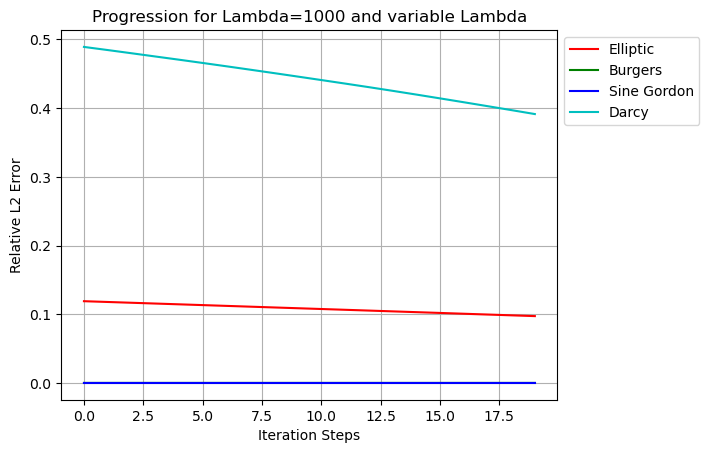

In [11]:

# Plotting
def plot_results(matrix, num_steps):
    # Convert matrix to numpy for easier plotting
    result_numpy = matrix.detach().numpy()

    # Define a list of colors for each alpha (7 values, 7 colors)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Red, Green, Blue, Cyan, Magenta, Yellow, Black

    # Plot for each alpha
    plt.plot(range(num_steps), result_numpy[0, :], label=f'Elliptic', color=colors[0])
    plt.plot(range(num_steps), result_numpy[1, :], label=f'Burgers', color=colors[1])
    plt.plot(range(num_steps), result_numpy[2, :], label=f'Sine Gordon', color=colors[2])
    plt.plot(range(num_steps), result_numpy[3, :], label=f'Darcy', color=colors[3])

    # Add labels and legend
    plt.xlabel('Iteration Steps')
    plt.ylabel('Relative L2 Error')
    plt.title('Progression for Lambda=1000 and variable Lambda')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()


# Call the plot function
plot_results(alpha_error_matrix, num_steps)

In [12]:
# Testing the model for the Nonlinear Elliptic Problem

def deep_newton_nonlinear_elliptic(model, N, f, v0, A_laplace, build_jacobian_coeffs_nonlinear_elliptic, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_nonlinear_elliptic(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1)
        with torch.no_grad():  # Disable gradients for inference
            U_sparse = model.forward(X)        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n



# Generating Solutions using the GP sampled data
num_test_data = 100

f_test, u_test, v = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)
v_vals2 = u_test
f_vals1 = torch.cat([(-A_laplace @ u_test[i, :] + Factor * u_test[i, :] ** 3).unsqueeze(0)
                     for i in range(u_test.size(0))], dim=0)


v_solutions = v_vals2
f_vals2 = f_vals1
u0 = torch.zeros_like(v_solutions[0])  # Initial guess v0


# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0

    
# Loop through each realization
for j in range(num_test_data):
    
    v_predict = deep_newton_nonlinear_elliptic(gp_model[0], N, f_vals2[j,:], u0, A_laplace, build_jacobian_coeffs_nonlinear_elliptic,  max_iter=200, c1 = 1e-4, beta = 0.3, learning_rate = 1)

        # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_solutions[j, :] - v_predict) / torch.norm(v_solutions[j, :]))
    l2error = torch.norm(v_solutions[j, :] - v_predict) 
    
    print(f"{j}, Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")
    


0, Total Rel. L2 err: 3.4860171280464175e-14, Total L2 err: 1.1791569211951696e-13
1, Total Rel. L2 err: 4.600380666006802e-12, Total L2 err: 3.18667508369488e-12
2, Total Rel. L2 err: 7.817454436901163e-15, Total L2 err: 3.9229381419667493e-14
3, Total Rel. L2 err: 7.988897170619828e-13, Total L2 err: 6.625845100113606e-13
4, Total Rel. L2 err: 1.855483272487662e-14, Total L2 err: 6.509858288851922e-14
5, Total Rel. L2 err: 0.03688620737143269, Total L2 err: 0.36316324074583767
6, Total Rel. L2 err: 8.854474318886021e-14, Total L2 err: 1.2253608753684752e-13
7, Total Rel. L2 err: 2.2988161172414686e-15, Total L2 err: 1.7241016496964224e-14
8, Total Rel. L2 err: 1.989125084373042e-13, Total L2 err: 4.453016737827993e-13
9, Total Rel. L2 err: 2.5804089920193564e-15, Total L2 err: 1.6770616107185176e-14
10, Total Rel. L2 err: 1.5040439177484997e-13, Total L2 err: 3.4053682658189635e-13
11, Total Rel. L2 err: 1.7708932911578712e-06, Total L2 err: 8.756654352659134e-07
12, Total Rel. L2 er

KeyboardInterrupt: 

In [19]:
# Testing the model for the Darcy Flow Problem


def deep_newton_darcy(model, N, a_coefficient, f, v0, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_darcy(a_coefficient, v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1)
                
        with torch.no_grad():  # Disable gradients for inference
            U_sparse = model.forward(X)
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]
             

        # Compute F and the Gradient of F at v_n
        A_L = matrix_darcy(a_coefficient, N, dx)
        F_n = - A_L @ v_n + Factor2 * v_n ** 3 - f     
        P = - A_L + torch.diag(3 * Factor2 * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f       # Evaluate F at current guess
  
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n



# Generating Solutions using the GP sampled data
 num_test_data = 100

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# f_vals1 = torch.cat([(-A_L @ u_test[i, :] + Factor2 * u_test[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_test.size(0))], dim=0)

a = a_realizations[1]
u0 = torch.zeros(N) # Initial guess v0


# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0

# Loop through each realization
for j in range(num_test_data):
    
    a = a_test[j]

    A_L = matrix_darcy(a, N, dx)
    f = f_realizations[0]
    v_classic = classic_newton_method_darcy(a, f, u0, max_iter=1000, learning_rate = 1)
    v_predict = deep_newton_darcy(gp_model[3], N, a, f, u0,  max_iter=200, c1 = 1e-4, beta = 0.3, learning_rate = 1)
    
    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_classic - v_predict) / torch.norm(v_classic))
    l2error = torch.norm(v_classic - v_predict) 
    
    
    
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}, Classical Prediction: {torch.norm(v_classic)}, Deep Prediction: {torch.norm(v_predict)}")

0, Deep Newton: Total Rel. L2 err: 0.9998876761124825, Total L2 err: 5.697226671325287, Classical Prediction: 5.6978666778611, Deep Prediction: 0.0006404544792055871
1, Deep Newton: Total Rel. L2 err: 5.268109036183095e-15, Total L2 err: 3.001649691964724e-14, Classical Prediction: 5.697774422185291, Deep Prediction: 5.69777442218532
2, Deep Newton: Total Rel. L2 err: 1.144717867503681e-14, Total L2 err: 6.522406726383435e-14, Classical Prediction: 5.697829055998779, Deep Prediction: 5.6978290559987155


KeyboardInterrupt: 

In [20]:
# Testing the model for the Burgers Equation 

# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method(f, u_prev, A_laplace, max_iter, learning_rate):
    v_n = u_prev.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        C = convection_matrix(v_n, N, dx)
        res = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        J = jacobianBurgers(v_n, A_laplace, dx, dt, nu)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

def deep_newton_method_sparse_cholesky(model, N, u, u_prev, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_prev.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_viscous_burgers_1d_periodic(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1) #  
        with torch.no_grad():  # Disable gradients for inference
            U_sparse = model.forward(X)
        
        # X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor

        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute the residual and its Jacobian
        C = convection_matrix(v_n, N, dx)
        F_n = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        P = jacobianBurgers(v_n, A_laplace, dx, dt, nu)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v
        C_trial = convection_matrix(v_trial, N, dx)
        F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)  # Evaluate F at current guess

        # F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  
        # for _ in range(10):  # Maximum of 5 iterations
        #     if torch.norm(F_n_delta) ** 2 <= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
        #         break  # Exit the loop if the condition is satisfied
        #     alpha *= beta  # Reduce step size
        #     v_trial = v_n - alpha * delta_v
        #     F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt)  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            C_trial = convection_matrix(v_trial, N, dx)
            F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)  # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

        # # Cleanup intermediate variables to free memory
        # del F_n, P, d, delta_v, F_n_delta, A_inv, U_dense, sparse_tensor
        # torch.cuda.empty_cache()

    return v_n


def time_forward_method_deep(model, N, N_T, u, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0

    for i in range(N_T - 1):
        u_sol[:, i + 1] = deep_newton_method_sparse_cholesky(model, N, u, u_sol[:, i], A_laplace, max_iter, c1, beta,
                                                             learning_rate)
        print(i)
    return u_sol


def time_forward_method_classic(u, u_prev, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u_prev.dtype, device=u_prev.device)
    u_sol[:, 0] = u_prev

    for i in range(N_T - 1):
        u_sol[:, i + 1] = classic_newton_method(u, u_sol[:, i], A_laplace, max_iter, learning_rate)

    return u_sol


functions = [
    lambda x: x,  # 0 Linear function
    lambda x: x ** 2,  # 1 Quadratic function
    lambda x: torch.sin(2 * torch.pi * x),  # 2 Sine function
    lambda x: torch.cos(2 * torch.pi * x),  # 3 Cosine function
    lambda x: torch.exp(torch.sin(2 * torch.pi * x)),  # 4 Exponential function
    lambda x: torch.log(x + 1),  # 5 Logarithmic function (shifted to avoid log(0))
    lambda x: torch.abs(x - 0.5),  # 6 Absolute value centered at 0.5
    lambda x: torch.sqrt(x),  # 7 Square root function
    lambda x: torch.heaviside(x - 0.5, torch.tensor(0.0)),  # 8  Heaviside step function at 0.5
    lambda x: torch.sin(5 * torch.pi * x) * torch.exp(-x),  # 9 Damped sine wave
    lambda x: torch.tanh(x),  # 10 Tanh
    lambda x: torch.sigmoid(x),  # 11 Sigmoid 
    lambda x: torch.sin(2 * torch.pi * x) + torch.cos(4 * torch.pi * x) ** 2,  # 12
    lambda x: torch.sin(10 * torch.pi * x),  # 13
    lambda x: x ** 2 * (1 - x) ** 3 + 10,  # 14
    lambda x: x ** 5 * (1 - x) ** 3,  # 15
]

u_initial = functions[4]
u0 = torch.vmap(u_initial)(x)
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)


u_sol = time_forward_method_classic(f, u0, A_laplace, max_iter=100, learning_rate=1.0)

u_pred = time_forward_method_deep(gp_model[1], N, N_T, u = f, u0 = u0, A_laplace = A_laplace, max_iter=100, c1=1e-4, beta=0.3, learning_rate=1) 


u0 = u_sol[:, 0]
u1 = u_sol[:, 30]
u2 = u_sol[:, 60]
u3 = u_pred[:, 0]
u4 = u_pred[:, 30]
u5 = u_pred[:, 60]

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
# Plot true solution in the first column of the i-th row
axes[0, 0].plot(x.numpy(), u0.detach().numpy(), label=f'u(t=0.33)')
axes[0, 0].set_xlabel('Grid point index')
axes[0, 0].set_ylabel('True Solution')
axes[0, 0].legend()

# Plot GP means in the first column of the i-th row
axes[0, 1].plot(x.numpy(), u1.detach().numpy(), label=f'u(t=0.66)', linestyle='--')
axes[0, 1].set_xlabel('Grid point index')
axes[0, 1].set_ylabel('True Solution')
axes[0, 1].legend()

# Plot gradient decent solutions in the second column of the i-th row
axes[0, 2].plot(x.numpy(), u2.detach().numpy(), label=f'u(t=1)', linestyle='--')
axes[0, 2].set_xlabel('Grid point index')
axes[0, 2].set_ylabel('True Solution')
axes[0, 2].legend()

# Plot fast gradient solutions in the second column of the i-th row
axes[1, 0].plot(x.numpy(), u3.detach().numpy(), label=f'u_pred(t=0.33)', linestyle='--')
axes[1, 0].set_xlabel('Grid point index')
axes[1, 0].set_ylabel('Prediction')
axes[1, 0].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1, 1].plot(x.numpy(), u4.detach().numpy(), label=f'u_pred(t=0.66)', linestyle='--')
axes[1, 1].set_xlabel('Grid point index')
axes[1, 1].set_ylabel(f'Prediction')
axes[1, 1].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1, 2].plot(x.numpy(), u5.detach().numpy(), label=f'u_pred(t=1)', linestyle='--')
axes[1, 2].set_xlabel('Grid point index')
axes[1, 2].set_ylabel(f'Prediction')
axes[1, 2].legend()

KeyboardInterrupt: 

In [28]:
plt.tight_layout()
plt.show()
time = 98
rl2error = (torch.norm(u_sol[:, time] - u_pred[:, time]) / torch.norm(u_sol[:, time]))
l2error = torch.norm(u_sol[:, time] - u_pred[:, time])

print(f"Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

<Figure size 640x480 with 0 Axes>

NameError: name 'u_pred' is not defined

In [29]:

# Testing the model for the Sine Gordon Equation

def deep_newton_method_Sine_Gordon(model, N, u_n_1, u_n, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_Sine_Gordon(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1)
        with torch.no_grad():  # Disable gradients for inference
            U_sparse = model.forward(X)
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute the residual and its Jacobian
        F_n = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        P = jacobian_Sine_Gordon(v_n, A_laplace, dt)
        

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v
        F_n_delta = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

      
        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n


def time_forward_method_deep_Sine_Gordon(model, N, N_T, v0, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0


    for i in range(N_T - 2):
        u_sol[:, i + 2] = deep_newton_method_Sine_Gordon(model, N, u_sol[:, i+1], u_sol[:, i], A_laplace, max_iter, c1, beta,
                                                             learning_rate)
        print(i)
    return u_sol


def time_forward_method_classic_Sine_Gordon(v0, u0, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        u_sol[:, i + 2] = classic_newton_method_Sine_Gordon(u_sol[:, i+1], u_sol[:, i], A_laplace, max_iter, learning_rate)
        
    return u_sol



functions = [
    lambda x: x,  # 0 Linear function
    lambda x: x ** 2,  # 1 Quadratic function
    lambda x: torch.sin(torch.pi * x),  # 2 Sine function
    lambda x: torch.cos(2 * torch.pi * x),  # 3 Cosine function
    lambda x: torch.exp(torch.sin(2 * torch.pi * x)),  # 4 Exponential function
    lambda x: torch.log(x + 1),  # 5 Logarithmic function (shifted to avoid log(0))
    lambda x: torch.abs(x - 0.5),  # 6 Absolute value centered at 0.5
    lambda x: torch.sqrt(x),  # 7 Square root function
    lambda x: torch.heaviside(x - 0.5, torch.tensor(0.0)),  # 8  Heaviside step function at 0.5
    lambda x: torch.sin(5 * torch.pi * x) * torch.exp(-x),  # 9 Damped sine wave
    lambda x: torch.tanh(x),  # 10 Tanh
    lambda x: torch.sigmoid(x),  # 11 Sigmoid 
    lambda x: torch.sin(2 * torch.pi * x) + torch.cos(4 * torch.pi * x) ** 2,  # 12
    lambda x: torch.sin(10 * torch.pi * x),  # 13
    lambda x: x ** 2 * (1 - x) ** 3 + 10,  # 14
    lambda x: x ** 5 * (1 - x) ** 3,  # 15
]

u_initial = functions[9]
u0 = -torch.vmap(u_initial)(x)
N_T = 100
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)

u_sol = time_forward_method_classic_Sine_Gordon(f, u0, A_laplace, max_iter=100, learning_rate=1.0)
M_T = 100

u_pred = time_forward_method_deep_Sine_Gordon(gp_model[1], N, M_T, f, u0, A_laplace = A_laplace, max_iter=100, c1=1e-4, beta=0.3, learning_rate=1) 

0
1
2
3
4
5
6
7
8
9


KeyboardInterrupt: 

In [30]:
u0 = u_sol[:, 33]
u1 = u_sol[:, 66]
u2 = u_sol[:, 99]
u3 = u_pred[:, 33]
u4 = u_pred[:, 66]
u5 = u_pred[:, 99]

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
# Plot true solution in the first column of the i-th row
axes[0, 0].plot(x.numpy(), u0.detach().numpy(), label=f'u(t=0.33)')
axes[0, 0].set_xlabel('Grid point index')
axes[0, 0].set_ylabel('True Solution')
axes[0, 0].legend()

# Plot GP means in the first column of the i-th row
axes[0, 1].plot(x.numpy(), u1.detach().numpy(), label=f'u(t=0.66)', linestyle='--')
axes[0, 1].set_xlabel('Grid point index')
axes[0, 1].set_ylabel('True Solution')
axes[0, 1].legend()

# Plot gradient decent solutions in the second column of the i-th row
axes[0, 2].plot(x.numpy(), u2.detach().numpy(), label=f'u(t=1)', linestyle='--')
axes[0, 2].set_xlabel('Grid point index')
axes[0, 2].set_ylabel('True Solution')
axes[0, 2].legend()

# Plot fast gradient solutions in the second column of the i-th row
axes[1, 0].plot(x.numpy(), u3.detach().numpy(), label=f'u_pred(t=0.33)', linestyle='--')
axes[1, 0].set_xlabel('Grid point index')
axes[1, 0].set_ylabel('Prediction')
axes[1, 0].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1, 1].plot(x.numpy(), u4.detach().numpy(), label=f'u_pred(t=0.66)', linestyle='--')
axes[1, 1].set_xlabel('Grid point index')
axes[1, 1].set_ylabel(f'Prediction')
axes[1, 1].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1, 2].plot(x.numpy(), u5.detach().numpy(), label=f'u_pred(t=1)', linestyle='--')
axes[1, 2].set_xlabel('Grid point index')
axes[1, 2].set_ylabel(f'Prediction')
axes[1, 2].legend()

plt.tight_layout()
plt.show()
time = 99
rl2error = (torch.norm(u_sol[:, time] - u_pred[:, time]) / torch.norm(u_sol[:, time]))
l2error = torch.norm(u_sol[:, time] - u_pred[:, time])

print(f"Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

NameError: name 'u_pred' is not defined

In [31]:
gp_list = []
gp_list.append(gp_model[0])
gp_list.append(gp_model[1])
# gp_model[2] = gp_model[3]
gp_list.append(gp_model[3])

X_data_list = []
X_data_list.append(X_train_elliptic)
X_data_list.append(X_train_burgers)
X_data_list.append(X_train_darcy)

K_cross_terms_list = []

ls_list = length_scales(gp_list)

# ls_list[0] = 1/2 * ls_list[2] + 1/2 * ls_list[2]

ls_list[0] = 1/3 * ls_list[0] + 1/3 * ls_list[1] + 1/3 * ls_list[2] 
ls_list[1] = ls_list[0]
ls_list[2] = ls_list[0]
# 
# ls_list[0] = ls_list[2] 
# ls_list[1] = ls_list[2]

K_inverses_list = kernel_inverses(ls_list, X_data_list)


for i in range(len(X_data_list)):
    for j in range(len(X_data_list)):
        K_cross_terms_list.append(kernel_cross_evaluation(ls_list[i], ls_list[j], X_data_list[i], X_data_list[j]))
        

In [33]:
# Testing the aggregated model for the Nonlinear Elliptic Problem

def deep_newton_nonlinear_elliptic(gp_model_list, X_data_list, N, f, v0, A_laplace, build_jacobian_coeffs_nonlinear_elliptic, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_nonlinear_elliptic(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        x = torch.cat([a, b, c], dim=1)
        
        U_sparse = model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n


alpha_error_matrix = torch.zeros(num_steps)


# Generating Solutions using the GP sampled data
 num_test_data = 100

f_test, u_test, v = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)
v_vals2 = u_test
f_vals1 = torch.cat([(-A_laplace @ u_test[i, :] + Factor * u_test[i, :] ** 3).unsqueeze(0)
                     for i in range(u_test.size(0))], dim=0)


v_solutions = v_vals2
f_vals2 = f_vals1
u0 = torch.zeros_like(v_solutions[0])  # Initial guess v0


# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0



# Loop through each realization
for j in range(num_test_data):
    
    v_predict = deep_newton_nonlinear_elliptic(gp_list, X_data_list, N, f_vals2[j,:], u0, A_laplace, build_jacobian_coeffs_nonlinear_elliptic,  max_iter=100, c1 = 1e-4, beta = 0.3, learning_rate = 1)

        # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_solutions[j, :] - v_predict) / torch.norm(v_solutions[j, :]))
    l2error = torch.norm(v_solutions[j, :] - v_predict) 
    
    print(f"{j}, Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")
    

KeyboardInterrupt: 

In [34]:
# generating quantile plots for FONKNORIS


def deep_newton_nonlinear_elliptic(gp_model_list, X_data_list, N, f, v0, v_true, A_laplace, build_jacobian_coeffs_nonlinear_elliptic, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()
    error_matrix = torch.zeros(max_iter)


    for i in range(max_iter):
        
        rl2error = (torch.norm(v_true - v_n) / torch.norm(v_true))
        error_matrix[i] = rl2error
        
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_nonlinear_elliptic(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        x = torch.cat([a, b, c], dim=1)
        
        U_sparse = model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v        
        

    return error_matrix




# Generating Solutions using the GP sampled data
num_test_data = 100
max_iter = 250

f_test, u_test, v = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)
v_vals2 = u_test
f_vals1 = torch.cat([(-A_laplace @ u_test[i, :] + Factor * u_test[i, :] ** 3).unsqueeze(0)
                     for i in range(u_test.size(0))], dim=0)


v_solutions = v_vals2
f_vals2 = f_vals1
u0 = torch.zeros_like(v_solutions[0])  # Initial guess v0

# Collect results into a list (each is a torch tensor)
v_predict_errors= [
    deep_newton_nonlinear_elliptic(
        gp_list,
        X_data_list,
        N,
        f_vals2[j, :],
        u0,
        v_solutions[j, :],
        A_laplace,
        build_jacobian_coeffs_nonlinear_elliptic,
        max_iter=max_iter,
        c1=1e-4,
        beta=0.3,
        learning_rate=1
    )
    for j in range(num_test_data)
]

# Stack them into a single tensor along a new dimension (like vstack in NumPy)
errors_elliptic = torch.stack(v_predict_errors, dim=0)

KeyboardInterrupt: 

In [35]:
# 2) Compute quantiles across runs (dim=0)
quantiles = [0.25, 0.75, 0.90, 0.95]
q_curves = [
    torch.nanquantile(errors_elliptic, q, dim=0).cpu().numpy()  # convert to NumPy for plotting
    for q in quantiles
]

# 3) Plot on log–log axes
iters = np.arange(1, errors_elliptic.shape[1] + 1)
linestyles = ['-', '--', ':', '-.']

# NEW: color list (blue, green, purple, orange)
colors = ['blue', 'green', 'purple', 'tab:orange']

plt.figure(figsize=(6,6))
for q, curve, ls, color in zip(quantiles, q_curves, linestyles, colors):
    # For log–log plotting, avoid zeros by clipping to a tiny positive floor
    curve_plot = np.clip(curve, 1e-16, np.inf)
    plt.loglog(
        iters,
        curve_plot,
        linestyle=ls,
        linewidth=3,
        color=color,
        label=f"{int(q*100)}%"
    )

plt.xlabel("iteration", fontsize=15)
plt.ylabel(r"$L_2$ relative error", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="quantile", loc="lower left", framealpha=0.9)

out_path = "newton_relative_error_quantiles_elliptic32_new.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")

print("Saved to:", out_path)


NameError: name 'errors_elliptic' is not defined

In [36]:
# Testing the model for the Darcy Flow Problem


def deep_newton_darcy(gp_model_list, X_data_list, N, a_coefficient, f, v0, build_jacobian_coeffs_darcy, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_darcy(a_coefficient, v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1)
        
        U_sparse = model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, X, X_data_list)
        
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]
             

        # Compute F and the Gradient of F at v_n
        A_L = matrix_darcy(a_coefficient, N, dx)
        F_n = - A_L @ v_n + Factor2 * v_n ** 3 - f     
        P = - A_L + torch.diag(3 * Factor2 * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f       # Evaluate F at current guess
  
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n



# Generating Solutions using the GP sampled data
num_test_data = 100

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# f_vals1 = torch.cat([(-A_L @ u_test[i, :] + Factor2 * u_test[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_test.size(0))], dim=0)

# a = a_realizations[1]
u0 = torch.zeros(N) # Initial guess v0


# Loop through each realization
for j in range(num_test_data):
    
    a = a_test[j]

    f = f_realizations[0]
    v_classic = classic_newton_method_darcy(a, f, u0, max_iter=1000, learning_rate = 1)
    v_predict = deep_newton_darcy(gp_list, X_data_list, N, a, f, u0, build_jacobian_coeffs_darcy, max_iter=200, c1 = 1e-4, beta = 0.3, learning_rate = 1)
    
        
    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_classic - v_predict) / torch.norm(v_classic))
    l2error = torch.norm(v_classic - v_predict) 
    
    
    
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}, Classical Prediction: {torch.norm(v_classic)}, Deep Prediction: {torch.norm(v_predict)}")

KeyboardInterrupt: 

In [37]:
# Generating Quantile Plots for Darcy Flow Problem


def deep_newton_darcy(gp_model_list, X_data_list, N, a_coefficient, f, v0, v_true, build_jacobian_coeffs_darcy, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()
    error_matrix = torch.zeros(max_iter)


    for i in range(max_iter):
        
        rl2error = (torch.norm(v_true - v_n) / torch.norm(v_true))
        error_matrix[i] = rl2error 
        
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_darcy(a_coefficient, v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        X = torch.cat([a, b, c], dim=1)
        
        U_sparse = model_aggregation(gp_model_list, ls_list, K_inverses_list, K_cross_terms_list, X, X_data_list)
        
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]
             

        # Compute F and the Gradient of F at v_n
        A_L = matrix_darcy(a_coefficient, N, dx)
        F_n = - A_L @ v_n + Factor2 * v_n ** 3 - f     
        P = - A_L + torch.diag(3 * Factor2 * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f       # Evaluate F at current guess
  
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_L @ v_trial + Factor2 * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return error_matrix



# Generating Solutions using the GP sampled data
num_test_data = 100
max_iter=1000

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# f_vals1 = torch.cat([(-A_L @ u_test[i, :] + Factor2 * u_test[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_test.size(0))], dim=0)

# a = a_realizations[1]
u0 = torch.zeros(N) # Initial guess v0
f = f_realizations[0]



# Collect results into a list (each is a torch tensor)
v_solutions_darcy= [classic_newton_method_darcy(a_test[j], f, u0, max_iter=1000, learning_rate = 1)
    for j in range(num_test_data)
]
        

# Collect results into a list (each is a torch tensor)
v_predict_errors_darcy= [
    deep_newton_darcy(
        gp_list,
        X_data_list,
        N,
        a_test[j],
        f,
        u0,
        v_solutions_darcy[j],
        build_jacobian_coeffs_darcy,
        max_iter=max_iter,
        c1=1e-4,
        beta=0.3,
        learning_rate=1
    )
    for j in range(num_test_data)
]

# Stack them into a single tensor along a new dimension (like vstack in NumPy)
errors_darcy = torch.stack(v_predict_errors_darcy, dim=0)

KeyboardInterrupt: 

Saved to: newton_relative_error_quantiles_darcy32_100samples_new2.png


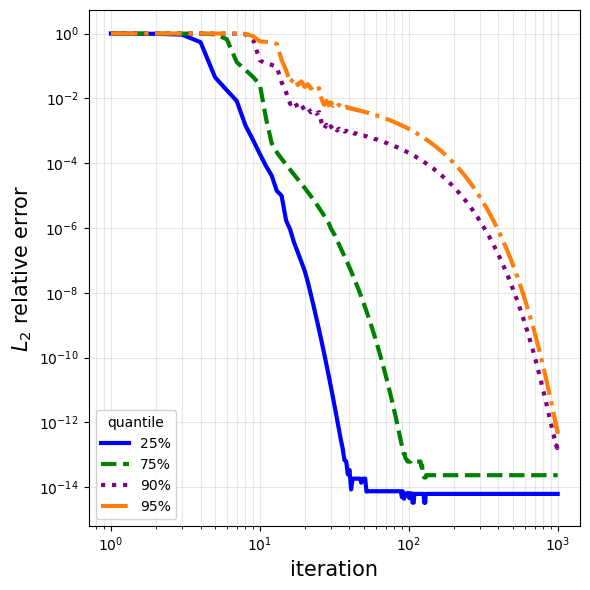

In [45]:

# 2) Compute quantiles across runs (dim=0)
quantiles = [0.25, 0.75, 0.90, 0.95]
q_curves_darcy = [
    torch.nanquantile(errors_darcy, q, dim=0).cpu().numpy()
    for q in quantiles
]

# Colors for each quantile
colors = ["blue", "green", "purple", "tab:orange"]
linestyles = ['-', '--', ':', '-.']

# 3) Plot on log–log axes
iters = np.arange(1, errors_darcy.shape[1] + 1)

plt.figure(figsize=(6,6))
for q, curve, ls, c in zip(quantiles, q_curves_darcy, linestyles, colors):
    curve_plot = np.clip(curve, 1e-16, np.inf)
    plt.loglog(
        iters,
        curve_plot,
        linestyle=ls,
        linewidth=3,
        color=c,              # <-- color here
        label=f"{int(q*100)}%"
    )

plt.xlabel("iteration", fontsize=15)
plt.ylabel(r"$L_2$ relative error", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="quantile", loc="lower left", framealpha=0.9)

out_path = "newton_relative_error_quantiles_darcy32_100samples_new2.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")

print("Saved to:", out_path)


In [46]:



# Testing the model for the Burgers Equation 
# Burgers Equation
# Parameters

T = 1.0  # Final time
dt = 1/100  # Time step size
N_T = 100  # Number of Time Points
nu = 0.02  # Viscosity


# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method(f, u_prev, A_laplace, max_iter, learning_rate):
    v_n = u_prev.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        C = convection_matrix(v_n, N, dx)
        res = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        J = jacobianBurgers(v_n, A_laplace, dx, dt, nu)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

def deep_newton_method_sparse_cholesky(gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list, N, u, u_prev, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_prev.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_viscous_burgers_1d_periodic(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        x = torch.cat([a, b, c], dim=1)
        
        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        # X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor

        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute the residual and its Jacobian
        C = convection_matrix(v_n, N, dx)
        F_n = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        P = jacobianBurgers(v_n, A_laplace, dx, dt, nu)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v
        C_trial = convection_matrix(v_trial, N, dx)
        F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)  # Evaluate F at current guess

        # F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  
        # for _ in range(10):  # Maximum of 5 iterations
        #     if torch.norm(F_n_delta) ** 2 <= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
        #         break  # Exit the loop if the condition is satisfied
        #     alpha *= beta  # Reduce step size
        #     v_trial = v_n - alpha * delta_v
        #     F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt)  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            C_trial = convection_matrix(v_trial, N, dx)
            F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)  # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

        # # Cleanup intermediate variables to free memory
        # del F_n, P, d, delta_v, F_n_delta, A_inv, U_dense, sparse_tensor
        # torch.cuda.empty_cache()

    return v_n


def time_forward_method_deep(gp_list, N, N_T, u, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0

    for i in range(N_T - 1):
        u_sol[:, i + 1] = deep_newton_method_sparse_cholesky(gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list, N, u, u_sol[:, i], A_laplace, max_iter, c1, beta,
                                                             learning_rate)
    return u_sol


def time_forward_method_classic(u, u_prev, N_T, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u_prev.dtype, device=u_prev.device)
    u_sol[:, 0] = u_prev

    for i in range(N_T - 1):
        u_sol[:, i + 1] = classic_newton_method(u, u_sol[:, i], A_laplace, max_iter, learning_rate)

    return u_sol


N_Final = N_T   #Final time, maximum N_T=100
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)


# Generating Solutions using the GP sampled data
num_test_data = 100

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# f_vals1 = torch.cat([(-A_L @ u_test[i, :] + Factor2 * u_test[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_test.size(0))], dim=0)

# a = a_realizations[1]

# Loop through each realization
for j in range(num_test_data):
    
    u0 = u_test[j]

    u_sol = time_forward_method_classic(f, u0, N_Final, A_laplace, max_iter=100, learning_rate=1.0)
    u_pred = time_forward_method_deep(gp_list, N, N_Final, u = f, u0 = u0, A_laplace = A_laplace, max_iter=5, c1=1e-4, beta=0.3, learning_rate=1) 
        
    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(u_sol - u_pred) / torch.norm(u_sol))
    l2error = torch.norm(u_sol - u_pred) 
    
    
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

0, Deep Newton: Total Rel. L2 err: 3.1299833353095137e-12, Total L2 err: 2.547333521852609e-10
1, Deep Newton: Total Rel. L2 err: 9.153797457780674e-12, Total L2 err: 3.388107801922339e-10
2, Deep Newton: Total Rel. L2 err: 1.9677139049495864e-11, Total L2 err: 1.4688694533565936e-09
3, Deep Newton: Total Rel. L2 err: 1.1873971808585749e-11, Total L2 err: 5.763273658088416e-10
4, Deep Newton: Total Rel. L2 err: 3.27928083069456e-11, Total L2 err: 6.048316737407253e-10
5, Deep Newton: Total Rel. L2 err: 1.9968097419499536e-11, Total L2 err: 2.045457514229637e-09
6, Deep Newton: Total Rel. L2 err: 1.2998453619869059e-11, Total L2 err: 1.1495599534228373e-09
7, Deep Newton: Total Rel. L2 err: 2.7712339802403035e-11, Total L2 err: 2.0427953155946946e-10
8, Deep Newton: Total Rel. L2 err: 2.6448170281197975e-11, Total L2 err: 3.2955574128966644e-10
9, Deep Newton: Total Rel. L2 err: 2.0664238712573417e-11, Total L2 err: 1.1223269937368375e-09


In [47]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------
T = 1.0       # Final time
dt = 1/100    # Time step size
nu = 0.02     # Viscosity

# Include t = 1.00 exactly
N_Final = int(round(T / dt)) + 1   # 0..100 -> 101 points
time_grid = torch.arange(N_Final, dtype=torch.float64) * dt

# Times we want to monitor
target_ts = [0.33, 0.66, 1.00]
def nearest_index(t_values, t):
    t_values = np.asarray(t_values, dtype=float)
    return int(np.abs(t_values - t).argmin())

target_indices = [nearest_index(time_grid.cpu().numpy(), t) for t in target_ts]
print("N_Final:", N_Final, " target_indices:", target_indices)


# -------------------------
# Helpers
# -------------------------
def pad_to_len_1d(x: torch.Tensor, L: int) -> torch.Tensor:
    """Pad 1D tensor with NaNs to have length L (or truncate if longer)."""
    n = x.numel()
    if n == L:
        return x
    if n > L:
        return x[:L]
    pad = torch.full((L - n,), float('nan'), dtype=x.dtype, device=x.device)
    return torch.cat([x, pad], dim=0)

def rel_err_trace_vs_truth(iterates: list[torch.Tensor], u_true: torch.Tensor) -> torch.Tensor:
    """Return 1D tensor of ||v_k - u_true|| / ||u_true|| for k=1..K (post-update values)."""
    denom = torch.norm(u_true)
    denom = denom if denom.item() > 0 else torch.tensor(1.0, device=u_true.device, dtype=u_true.dtype)
    errs = [torch.norm(v - u_true) / denom for v in iterates]
    return torch.stack(errs)

# -------------------------
# Your existing functions assumed present:
#   convection_matrix, residualBurgers, jacobianBurgers,
#   build_jacobian_coeffs_viscous_burgers_1d_periodic,
#   model_aggregation, non_zeros, laplacian_matrix,
#   generate_dataset_from_gp, etc.
# -------------------------

def classic_newton_method(f, u_prev, A_laplace, max_iter, learning_rate):
    v_n = u_prev.clone()
    for _ in range(max_iter):
        C = convection_matrix(v_n, N, dx)
        res = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        J   = jacobianBurgers(v_n, A_laplace, dx, dt, nu)
        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()
    return v_n

def deep_newton_method_sparse_cholesky(
    gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list,
    N, u, u_prev, A_laplace, max_iter, c1, beta, learning_rate, return_trace: bool = False
):
    """
    If return_trace=True, also returns a list of per-iteration v_n (post-update) tensors.
    """
    v_n = u_prev.clone()
    iterates = [] if return_trace else None

    for _ in range(max_iter):
        # Prepare inputs for GP prediction
        a, b, c = build_jacobian_coeffs_viscous_burgers_1d_periodic(v_n)
        x = torch.cat([a.unsqueeze(0), b.unsqueeze(0), c.unsqueeze(0)], dim=1)

        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)

        # Convert sparse tensor to dense
        nonzeros_indices =  non_zeros(N, sparsity)
        U_dense = torch.sparse_coo_tensor(nonzeros_indices, U_sparse.flatten(), size=(N, N)).to_dense()
        invPerm = torch.argsort(Perm)

        # Construct A_inv (assumed learned)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Residual and Jacobian
        C = convection_matrix(v_n, N, dx)
        F_n = residualBurgers(v_n, u_prev, A_laplace, C, dt)
        P   = jacobianBurgers(v_n, A_laplace, dx, dt, nu)

        # Right-hand side
        d = (P.T @ F_n).detach()

        # Preconditioned step
        delta_v = (A_inv @ d).detach()

        # Backtracking (as in your current version; if you had Armijo sign fixes, keep them here)
        alpha = learning_rate
        v_trial = v_n - alpha * delta_v
        C_trial = convection_matrix(v_trial, N, dx)
        F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta
            v_trial = v_n - alpha * delta_v
            C_trial = convection_matrix(v_trial, N, dx)
            F_n_delta = residualBurgers(v_trial, u_prev, A_laplace, C_trial, dt)

        v_n = v_trial

        if return_trace:
            iterates.append(v_n.clone())

    if return_trace:
        return v_n, iterates
    return v_n

def time_forward_method_deep(gp_list, N, N_T, u, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    for i in range(N_T - 1):
        u_sol[:, i + 1] = deep_newton_method_sparse_cholesky(
            gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list,
            N, u, u_sol[:, i], A_laplace, max_iter, c1, beta, learning_rate
        )
    return u_sol

def time_forward_method_classic(u, u_prev, N_T, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u_prev.dtype, device=u_prev.device)
    u_sol[:, 0] = u_prev
    for i in range(N_T - 1):
        u_sol[:, i + 1] = classic_newton_method(u, u_sol[:, i], A_laplace, max_iter, learning_rate)
    return u_sol

# -------------------------
# Data & operators
# -------------------------
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N, device=A_laplace.device, dtype=A_laplace.dtype)

num_test_data = 100
f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# Map time index -> slot (for matrix indexing)
target_slots = {idx: k for k, idx in enumerate(target_indices)}
Tslots = len(target_indices)

# Per-time quantile data as a matrix: (Tslots, num_test_data, max_iter_deep)
max_iter_deep_burgers = 10  # must match deep solver call

errors_tensor_burgers = torch.full(
    (Tslots, num_test_data, max_iter_deep_burgers),
    float('nan'),
    dtype=torch.float64,
    device=u_test.device if hasattr(u_test, "device") else "cpu"
)

# -------------------------
# Main loop over realizations
# -------------------------
for j in range(num_test_data):
    u0 = u_test[j]

    # Reference (classic) solution across all times
    u_sol = time_forward_method_classic(f, u0, N_Final, A_laplace, max_iter=100, learning_rate=1.0)

    # Deep solution (manual march so we can capture traces at selected times)
    u_pred = torch.zeros((N, N_Final), dtype=u0.dtype, device=u0.device)
    u_pred[:, 0] = u0

    for i in ran
        ge(N_Final - 1):
        # The Newton run at i produces u[:, i+1]
        if (i + 1) in target_slots:
            v_next, iterates = deep_newton_method_sparse_cholesky(
                gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list,
                N, f, u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_burgers, c1=1e-4, beta=0.3, learning_rate=1.0,
                return_trace=True
            )
            u_pred[:, i + 1] = v_next

            # Per-iteration relative errors vs truth at t_{i+1}
            err_trace = rel_err_trace_vs_truth(iterates, u_sol[:, i + 1])
            err_trace = pad_to_len_1d(err_trace, max_iter_deep_burgers)

            # write into the matrix: [time_slot, realization, :]
            kslot_burgers = target_slots[i + 1]
            errors_tensor_burgers[kslot_burgers, j, :] = err_trace
        else:
            v_next = deep_newton_method_sparse_cholesky(
                gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list,
                N, f, u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_burgers, c1=1e-4, beta=0.3, learning_rate=1.0,
                return_trace=False
            )
            u_pred[:, i + 1] = v_next

    # (optional) quick totals
    rl2error = torch.norm(u_sol - u_pred) / torch.norm(u_sol)
    l2error  = torch.norm(u_sol - u_pred)
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error.item():.3e}, Total L2 err: {l2error.item():.3e}")

N_Final: 101  target_indices: [33, 66, 100]
0, Deep Newton: Total Rel. L2 err: 2.003e-16, Total L2 err: 9.912e-15
1, Deep Newton: Total Rel. L2 err: 2.251e-16, Total L2 err: 1.679e-14
2, Deep Newton: Total Rel. L2 err: 2.727e-16, Total L2 err: 1.896e-14
3, Deep Newton: Total Rel. L2 err: 1.338e-16, Total L2 err: 5.946e-15


KeyboardInterrupt: 

Saved plot to: results/plots/burgers_newton_quantiles_t100_linearx_new.png


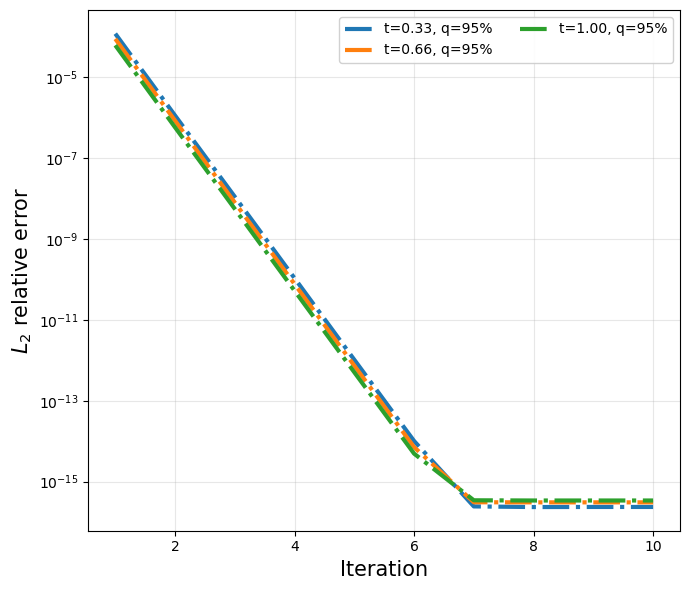

In [48]:
# Include t = 1.00 exactly
N_Final = int(round(T / dt)) + 1   # 0..100 -> 101 points
time_grid = torch.arange(N_Final, dtype=torch.float64) * dt

# Times we want to monitor
target_ts = [0.33, 0.66, 1.00]
def nearest_index(t_values, t):
    t_values = np.asarray(t_values, dtype=float)
    return int(np.abs(t_values - t).argmin())

target_indices = [nearest_index(time_grid.cpu().numpy(), t) for t in target_ts]

# Map time index -> slot (for matrix indexing)
target_slots = {idx: k for k, idx in enumerate(target_indices)}
Tslots = len(target_indices)

max_iter_deep_burgers = 10

# -------------------------
# Quantiles & Plot (25, 75, 90, 95%) at t=1.00
# -------------------------
iters = np.arange(1, max_iter_deep_burgers + 1)
quantiles = [0.95]
linestyles = {0.25: '-', 0.75: '--', 0.90: ':', 0.95: '-.'}

plt.figure(figsize=(7, 6))

for kslot, t_idx in enumerate(target_indices):
    # Skip empty slot (all-NaN)
    if torch.isnan(errors_tensor_burgers[kslot]).all():
        continue

    for q in quantiles:
        qcurve_burgers = torch.nanquantile(errors_tensor_burgers[kslot], q, dim=0).cpu().numpy()  # across realizations
        qcurve_burgers = np.maximum(qcurve_burgers, 1e-16)  # keep log(y) happy
        plt.semilogy(
            iters, qcurve_burgers,
            linestyle=linestyles[q], linewidth=3,
            label=f"t={time_grid[t_idx].item():.2f}, q={int(q*100)}%"
        )

# plt.title(r"Quantiles of $L_2$ relative errors (linear iterations, log error)")
plt.xlabel("Iteration", fontsize=15)
plt.ylabel(r"$L_2$ relative error", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best", framealpha=0.9, ncol=2)

# Save
out_dir = "results/plots"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "burgers_newton_quantiles_t100_linearx_new.png")
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved plot to:", out_path)


In [52]:
# Testing the model for the Sine Gordon Equation

# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method_Sine_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Solve the Newton iteration

        res = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Sine_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n


def deep_newton_method_Sine_Gordon(gp_list, N, u_n_1, u_n, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_Sine_Gordon(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        x = torch.cat([a, b, c], dim=1)
        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute the residual and its Jacobian
        F_n = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        P = jacobian_Sine_Gordon(v_n, A_laplace, dt)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v
        F_n_delta = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n


def time_forward_method_deep_Sine_Gordon(model, N, N_T, v0, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        u_sol[:, i + 2] = deep_newton_method_Sine_Gordon(model, N, u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter,
                                                         c1, beta,
                                                         learning_rate)
    return u_sol


def time_forward_method_classic_Sine_Gordon(v0, u0, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        u_sol[:, i + 2] = classic_newton_method_Sine_Gordon(u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter,
                                                            learning_rate)

    return u_sol


A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)


# Generating Solutions using the GP sampled data
num_test_data = 100

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# Loop through each realization
for j in range(num_test_data):
    
    
    u0 = u_test[j]

    u_sol = time_forward_method_classic_Sine_Gordon(f, u0, A_laplace, max_iter=100, learning_rate=1.0)
    u_pred = time_forward_method_deep_Sine_Gordon(gp_list, N, N_T, f, u0, A_laplace=A_laplace, max_iter=20, c1=1e-4,
                                              beta=0.3, learning_rate=1)
        
    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(u_sol - u_pred) / torch.norm(u_sol))
    l2error = torch.norm(u_sol - u_pred) 
    
    
    
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")


0, Deep Newton: Total Rel. L2 err: 3.544901308545856e-11, Total L2 err: 2.3911606329100255e-09
1, Deep Newton: Total Rel. L2 err: 7.662164177393401e-10, Total L2 err: 2.7463533370755502e-09
2, Deep Newton: Total Rel. L2 err: 2.8605229419204786e-11, Total L2 err: 1.7711953271323999e-09
3, Deep Newton: Total Rel. L2 err: 8.670621140533258e-11, Total L2 err: 3.5716866685070316e-09
4, Deep Newton: Total Rel. L2 err: 3.2650835154818144e-11, Total L2 err: 2.548350477235575e-09
5, Deep Newton: Total Rel. L2 err: 4.32494064529509e-11, Total L2 err: 2.281445577454927e-09
6, Deep Newton: Total Rel. L2 err: 1.6033260094959262e-10, Total L2 err: 3.0346745257998787e-09
7, Deep Newton: Total Rel. L2 err: 9.626690143216817e-10, Total L2 err: 3.5413735040442866e-09
8, Deep Newton: Total Rel. L2 err: 1.7654774398149506e-10, Total L2 err: 3.055368414794552e-09
9, Deep Newton: Total Rel. L2 err: 2.8265221916291003e-11, Total L2 err: 1.3282340016127579e-09


In [56]:
# Generating plots for Sine Gordon Equation
# Generating plots for Sine Gordon Equation

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# Helpers
# -------------------------
def pad_to_len_1d(x: torch.Tensor, L: int) -> torch.Tensor:
    n = x.numel()
    if n == L: return x
    if n > L:  return x[:L]
    pad = torch.full((L - n,), float('nan'), dtype=x.dtype, device=x.device)
    return torch.cat([x, pad], dim=0)

def rel_err_trace_vs_truth(iterates: list[torch.Tensor], u_true: torch.Tensor) -> torch.Tensor:
    denom = torch.norm(u_true)
    denom = denom if denom.item() > 0 else torch.tensor(1.0, device=u_true.device, dtype=u_true.dtype)
    errs = [torch.norm(v - u_true) / denom for v in iterates]
    return torch.stack(errs)

def nearest_index(t_values, t):
    t_values = np.asarray(t_values, dtype=float)
    return int(np.abs(t_values - t).argmin())

# -------------------------
# Your existing functions assumed present:
# residual_Sine_Gordon, jacobian_Sine_Gordon,
# build_jacobian_coeffs_Sine_Gordon, model_aggregation,
# non_zeros, laplacian_matrix, generate_dataset_from_gp,
# and constants: dt, c, N, dx, sparsity, Perm, gp_list, ls_list, K_inverses_list, K_cross_terms_list, X_data_list
# -------------------------

# --- Classic Newton (unchanged) ---
def classic_newton_method_Sine_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()
    for _ in range(max_iter):
        F_n = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J   = jacobian_Sine_Gordon(v_n, A_laplace, dt)
        delta_v = torch.linalg.solve(J, -F_n)
        v_n = v_n + learning_rate * delta_v.squeeze()
    return v_n

# --- Deep Newton with trace + Armijo (linear x, log y plotting later) ---
def deep_newton_method_Sine_Gordon(
    gp_list, N, u_n_1, u_n, A_laplace, max_iter, c1, beta, learning_rate,
    return_trace: bool = False
):
    v_n = u_n_1.clone()
    iterates = [] if return_trace else None

    for _ in range(max_iter):
        # GP-based inverse approximation
        a, b, c_feats = build_jacobian_coeffs_Sine_Gordon(v_n)
        x = torch.cat([a.unsqueeze(0), b.unsqueeze(0), c_feats.unsqueeze(0)], dim=1)
        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        nonzeros_indices =  non_zeros(N, sparsity)
        U_dense = torch.sparse_coo_tensor(nonzeros_indices, U_sparse.flatten(), size=(N, N)).to_dense()
        invPerm = torch.argsort(Perm)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]  # SPD approx

        # Residual, Jacobian, and search direction
        F_n = residual_Sine_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        P   = jacobian_Sine_Gordon(v_n, A_laplace, dt)
        d   = (P.T @ F_n).detach()          # gradient/2 of phi
        delta_v = (A_inv @ d).detach()
        s = -delta_v                        # descent direction

        # Backtracking Armijo on phi(v)=||F(v)||^2
        alpha = learning_rate
        v_trial = v_n + alpha * s
        F_trial = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)

        phi_n   = torch.norm(F_n)**2
        g_dot_s = torch.dot(d, s)          # should be <= 0 if A_inv is SPD

        # Armijo: phi(v+αs) <= phi(v) + 2 c1 α g^T s   (g = d)
        while torch.norm(F_trial)**2 > phi_n + 2 * c1 * alpha * g_dot_s:
            alpha *= beta
            v_trial = v_n + alpha * s
            F_trial = residual_Sine_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)

        v_n = v_trial
        if return_trace:
            iterates.append(v_n.clone())

    if return_trace:
        return v_n, iterates
    return v_n

# --- Time marching (classic reference) ---
def time_forward_method_classic_Sine_Gordon(v0, u0, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0
    for i in range(N_T - 2):
        u_sol[:, i + 2] = classic_newton_method_Sine_Gordon(u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter, learning_rate)
    return u_sol

# -------------------------
# Build time grid & targets
# -------------------------
# Ensure N_T and dt reflect your horizon; if you want t=1.0 exactly:
# N_T = int(round(1.0/dt)) + 1
time_grid = torch.arange(N_T, dtype=torch.float64) * dt
target_ts = [0.33, 0.66, 1.00]
target_indices = [nearest_index(time_grid.cpu().numpy(), t) for t in target_ts]

# -------------------------
# Data & operators
# -------------------------
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N, device=A_laplace.device, dtype=A_laplace.dtype)  # we'll use as v0=0
num_test_data = 100
f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)


# Map time index -> slot for matrix storage
target_slots = {idx: k for k, idx in enumerate(target_indices)}
Tslots = len(target_indices)

# Per-time quantile data matrix: (Tslots, num_test_data, max_iter_deep)
max_iter_deep_sine = 20
errors_tensor_sine = torch.full(
    (Tslots, num_test_data, max_iter_deep_sine),
    float('nan'),
    dtype=torch.float64,
    device=u_test.device if hasattr(u_test, "device") else "cpu"
)

# -------------------------
# Main loop over realizations
# -------------------------
for j in range(num_test_data):
    u0 = u_test[j]
    v0 = torch.zeros_like(u0)

    # Reference (classic) solution across all times
    u_ref = time_forward_method_classic_Sine_Gordon(v0, u0, A_laplace, max_iter=100, learning_rate=1.0)

    # Deep solution marched manually so we can capture traces
    u_pred = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_pred[:, 0] = u0
    u_pred[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        # Newton at step i computes u[:, i+2] from (u[:, i+1], u[:, i])
        if (i + 2) in target_slots:
            v_next, iterates = deep_newton_method_Sine_Gordon(
                gp_list, N, u_pred[:, i + 1], u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_sine, c1=1e-4, beta=0.5, learning_rate=1.0,
                return_trace=True
            )
            u_pred[:, i + 2] = v_next

            err_trace = rel_err_trace_vs_truth(iterates, u_ref[:, i + 2])
            err_trace = pad_to_len_1d(err_trace, max_iter_deep_sine)

            kslot_sine = target_slots[i + 2]
            errors_tensor_sine[kslot_sine, j, :] = err_trace
        else:
            v_next = deep_newton_method_Sine_Gordon(
                gp_list, N, u_pred[:, i + 1], u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_sine, c1=1e-4, beta=0.5, learning_rate=1.0,
                return_trace=False
            )
            u_pred[:, i + 2] = v_next
            

Saved plot to: results/plots/sine_gordon_newton_quantiles_t033_t066_t100_linearx_new.png


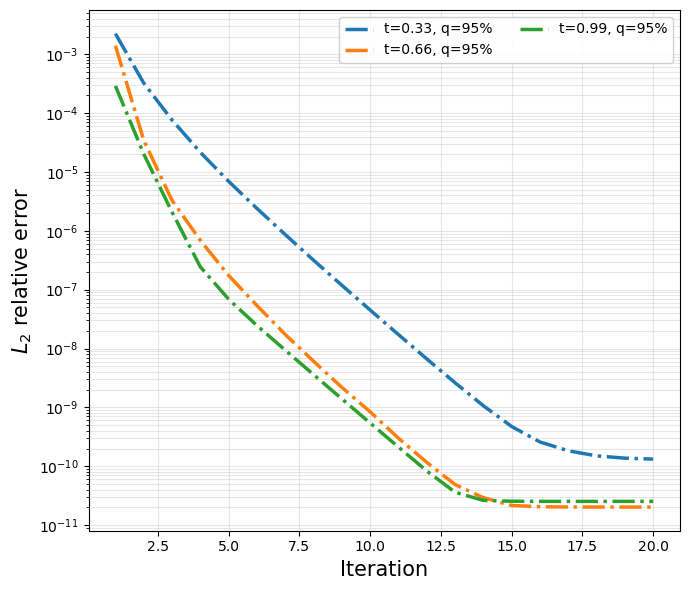

In [57]:


# -------------------------
# Plot 25%, 75%, 90%, 95% quantiles (linear x, log y)
# -------------------------
max_iter_deep_sine = 20
iters_sine = np.arange(1, max_iter_deep_sine + 1)
quantiles = [0.95]
linestyles = {0.25: '-', 0.75: '--', 0.90: ':', 0.95: '-.'}

plt.figure(figsize=(7, 6))

for kslot, t_idx in enumerate(target_indices):
    # Skip if no data for this time slot (all NaNs)
    if torch.isnan(errors_tensor_sine[kslot]).all():
        continue

    for q in quantiles:
        # Quantile across realizations (dim=0) at each iteration
        qcurve_sine = torch.nanquantile(errors_tensor_sine[kslot], q, dim=0).cpu().numpy()
        qcurve_sine = np.maximum(qcurve_sine, 1e-16)  # keep log(y) happy

        plt.semilogy(
            iters_sine, qcurve_sine,
            linestyle=linestyles[q], linewidth=2.5,
            label=f"t={time_grid[t_idx].item():.2f}, q={int(q*100)}%"
        )

# plt.title(r"Sine–Gordon: Quantiles of $L_2$ relative errors (linear iterations, log error)")
plt.xlabel("Iteration", fontsize=15)
plt.ylabel(r"$L_2$ relative error", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best", framealpha=0.9, ncol=2)

os.makedirs("results/plots", exist_ok=True)
out_path = "results/plots/sine_gordon_newton_quantiles_t033_t066_t100_linearx_new.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved plot to:", out_path)


In [58]:
# Testing FONKNORIS on Klein Gordon Equation


# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method_Klein_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Solve the Newton iteration

        res = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J = jacobian_Klein_Gordon(v_n, A_laplace, dt)

        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

def deep_newton_method_Klein_Gordon(gp_list, N, u_n_1, u_n, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_n_1.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        a, b, c = build_jacobian_coeffs_Klein_Gordon(v_n)
        a = a.unsqueeze(0)
        b = b.unsqueeze(0)
        c = c.unsqueeze(0)
        x = torch.cat([a, b, c], dim=1)
        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)
        # Convert sparse tensor to dense for validation
        nonzeros_indices =  non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute the residual and its Jacobian
        F_n = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        P = jacobian_Klein_Gordon(v_n, A_laplace, dt)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v
        F_n_delta = residual_Klein_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = residual_Klein_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)  # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n


def time_forward_method_deep_Klein_Gordon(model, N, N_T, v0, u0, A_laplace, max_iter, c1, beta, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        u_sol[:, i + 2] = deep_newton_method_Sine_Gordon(model, N, u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter,
                                                         c1, beta,
                                                         learning_rate)
    return u_sol


def time_forward_method_classic_Klein_Gordon(v0, u0, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        u_sol[:, i + 2] = classic_newton_method_Sine_Gordon(u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter,
                                                            learning_rate)

    return u_sol


A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)

# Generating Solutions using the GP sampled data
num_test_data = 100

f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# Loop through each realization
for j in range(num_test_data):
    u0 = u_test[j]

    u_sol = time_forward_method_classic_Klein_Gordon(f, u0, A_laplace, max_iter=100, learning_rate=1.0)
    u_pred = time_forward_method_deep_Klein_Gordon(gp_list, N, N_T, f, u0, A_laplace=A_laplace, max_iter=6, c1=1e-4,
                                                  beta=0.3, learning_rate=1)

    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(u_sol - u_pred) / torch.norm(u_sol))
    l2error = torch.norm(u_sol - u_pred)

    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")


0, Deep Newton: Total Rel. L2 err: 0.00027465259909201586, Total L2 err: 0.0013912312445645367
1, Deep Newton: Total Rel. L2 err: 9.14709146561542e-06, Total L2 err: 0.0013268216543778676
2, Deep Newton: Total Rel. L2 err: 4.800150697927464e-05, Total L2 err: 0.0010492355470350244
3, Deep Newton: Total Rel. L2 err: 4.2486777164472065e-05, Total L2 err: 0.001441278338009001
4, Deep Newton: Total Rel. L2 err: 0.00023277744571461556, Total L2 err: 0.0020196486459175622
5, Deep Newton: Total Rel. L2 err: 1.2717178845040459e-05, Total L2 err: 0.0009426288638093959
6, Deep Newton: Total Rel. L2 err: 1.670992492306916e-05, Total L2 err: 0.0013684815734775087
7, Deep Newton: Total Rel. L2 err: 5.19492519357701e-05, Total L2 err: 0.0014189614202776385
8, Deep Newton: Total Rel. L2 err: 3.3409138806524595e-05, Total L2 err: 0.0015451438405773281
9, Deep Newton: Total Rel. L2 err: 5.0128729102014106e-05, Total L2 err: 0.0011665355004134438


In [ ]:
# === Klein–Gordon quantile plots (linear x, log y) ===
# Assumes you already have: dt, c, N, dx, N_T, gp_list, ls_list, K_inverses_list,
# K_cross_terms_list, X_data_list, sparsity, Perm and helpers:
# residual_Klein_Gordon, jacobian_Klein_Gordon, build_jacobian_coeffs_Klein_Gordon,
# model_aggregation, non_zeros, laplacian_matrix, generate_dataset_from_gp

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# Helpers
# -------------------------
def pad_to_len_1d(x: torch.Tensor, L: int) -> torch.Tensor:
    n = x.numel()
    if n == L: return x
    if n > L:  return x[:L]
    pad = torch.full((L - n,), float('nan'), dtype=x.dtype, device=x.device)
    return torch.cat([x, pad], dim=0)

def rel_err_trace_vs_truth(iterates: list[torch.Tensor], u_true: torch.Tensor) -> torch.Tensor:
    denom = torch.norm(u_true)
    if denom.item() == 0:
        denom = torch.tensor(1.0, device=u_true.device, dtype=u_true.dtype)
    errs = [torch.norm(v - u_true) / denom for v in iterates]
    return torch.stack(errs)

def nearest_index(t_values, t):
    t_values = np.asarray(t_values, dtype=float)
    return int(np.abs(t_values - t).argmin())

# -------------------------
# Classic KG Newton
# -------------------------
def classic_newton_method_Klein_Gordon(u_n_1, u_n, A_laplace, max_iter, learning_rate):
    v_n = u_n_1.clone()
    for _ in range(max_iter):
        F_n = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        J   = jacobian_Klein_Gordon(v_n, A_laplace, dt)
        delta_v = torch.linalg.solve(J, -F_n)
        v_n = v_n + learning_rate * delta_v.squeeze()
    return v_n

# -------------------------
# Deep KG Newton with trace + Armijo (correct sign)
# -------------------------
def deep_newton_method_Klein_Gordon(
    gp_list, N, u_n_1, u_n, A_laplace, max_iter, c1, beta, learning_rate,
    return_trace: bool = False
):
    v_n = u_n_1.clone()
    iterates = [] if return_trace else None

    for _ in range(max_iter):
        # GP-based inverse approximation
        a, b, c_feats = build_jacobian_coeffs_Klein_Gordon(v_n)
        x = torch.cat([a.unsqueeze(0), b.unsqueeze(0), c_feats.unsqueeze(0)], dim=1)
        U_sparse = model_aggregation(gp_list, ls_list, K_inverses_list, K_cross_terms_list, x, X_data_list)

        nonzeros_indices =  non_zeros(N, sparsity)
        U_dense = torch.sparse_coo_tensor(nonzeros_indices, U_sparse.flatten(), size=(N, N)).to_dense()
        invPerm = torch.argsort(Perm)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]   # SPD-ish preconditioner

        # Residual / Jacobian / search direction
        F_n = residual_Klein_Gordon(v_n, u_n_1, u_n, A_laplace, dt)
        P   = jacobian_Klein_Gordon(v_n, A_laplace, dt)
        d   = (P.T @ F_n).detach()            # gradient/2 of phi(v)=||F||^2
        delta_v = (A_inv @ d).detach()
        s = -delta_v                           # descent direction

        # Armijo backtracking on phi(v)=||F(v)||^2
        alpha   = learning_rate
        v_trial = v_n + alpha * s
        F_trial = residual_Klein_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)

        phi_n   = torch.norm(F_n)**2
        g_dot_s = torch.dot(d, s)             # should be <= 0 if A_inv is SPD

        # Armijo: phi(v+αs) <= phi(v) + 2*c1*α*(d·s)
        while torch.norm(F_trial)**2 > phi_n + 2 * c1 * alpha * g_dot_s:
            alpha   *= beta
            v_trial  = v_n + alpha * s
            F_trial  = residual_Klein_Gordon(v_trial, u_n_1, u_n, A_laplace, dt)

        v_n = v_trial
        if return_trace:
            iterates.append(v_n.clone())

    if return_trace:
        return v_n, iterates
    return v_n

# -------------------------
# Time marching (classic reference)
# -------------------------
def time_forward_method_classic_Klein_Gordon(v0, u0, A_laplace, max_iter, learning_rate):
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:, 0] = u0
    u_sol[:, 1] = dt * v0 + u0
    for i in range(N_T - 2):
        u_sol[:, i + 2] = classic_newton_method_Klein_Gordon(
            u_sol[:, i + 1], u_sol[:, i], A_laplace, max_iter, learning_rate
        )
    return u_sol

# -------------------------
# Build time grid & targets
# -------------------------
# Ensure N_T and dt reflect your horizon; to include t=1 exactly:
# N_T = int(round(1.0/dt)) + 1
time_grid = torch.arange(N_T, dtype=torch.float64) * dt
target_ts = [0.33, 0.66, 1.00]
target_indices = [nearest_index(time_grid.cpu().numpy(), t) for t in target_ts]

# -------------------------
# Data & operators
# -------------------------
A_laplace = laplacian_matrix(N, dx)
v0_global = torch.zeros(N, device=A_laplace.device)  # initial velocity; adjust if needed
num_test_data = 100
f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

# Map time index -> slot for matrix storage
target_slots = {idx: k for k, idx in enumerate(target_indices)}
Tslots = len(target_indices)

# Matrix of per-iteration errors: (Tslots, num_test_data, max_iter_deep)
max_iter_deep_klein = 20
errors_tensor_klein = torch.full(
    (Tslots, num_test_data, max_iter_deep_klein),
    float('nan'),
    dtype=torch.float64,
    device=u_test.device if hasattr(u_test, "device") else "cpu"
)

# -------------------------
# Main loop over realizations
# -------------------------
for j in range(num_test_data):
    u0 = u_test[j]
    v0 = v0_global.clone()

    # Reference solution (classic KG)
    u_ref = time_forward_method_classic_Klein_Gordon(v0, u0, A_laplace, max_iter=100, learning_rate=1.0)

    # Manual deep march to capture traces at selected times
    u_pred = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_pred[:, 0] = u0
    u_pred[:, 1] = dt * v0 + u0

    for i in range(N_T - 2):
        # Newton at step i computes u[:, i+2] from (u[:, i+1], u[:, i])
        if (i + 2) in target_slots:
            v_next, iterates = deep_newton_method_Klein_Gordon(
                gp_list, N, u_pred[:, i + 1], u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_klein, c1=1e-4, beta=0.5, learning_rate=1.0,
                return_trace=True
            )
            u_pred[:, i + 2] = v_next

            err_trace = rel_err_trace_vs_truth(iterates, u_ref[:, i + 2])
            err_trace = pad_to_len_1d(err_trace, max_iter_deep_klein)

            kslot = target_slots[i + 2]
            errors_tensor_klein[kslot, j, :] = err_trace
        else:
            v_next = deep_newton_method_Klein_Gordon(
                gp_list, N, u_pred[:, i + 1], u_pred[:, i], A_laplace,
                max_iter=max_iter_deep_klein, c1=1e-4, beta=0.5, learning_rate=1.0,
                return_trace=False
            )
            u_pred[:, i + 2] = v_next

Saved plot to: results/plots/klein_gordon_newton_quantiles_t033_t066_t100_linearx2_new.png


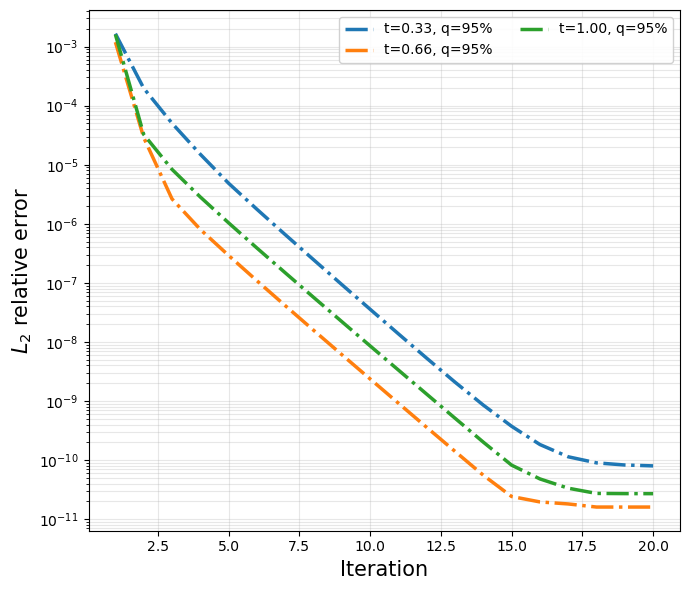

In [ ]:


# -------------------------
# Plot 25%, 75%, 90%, 95% quantiles (linear x, log y)
# -------------------------
max_iter_deep_klein = 20
iters_klein = np.arange(1, max_iter_deep_klein + 1)
quantiles = [0.95]
linestyles = {0.25: '-', 0.75: '--', 0.90: ':', 0.95: '-.'}


plt.figure(figsize=(7, 6))

for kslot, t_idx in enumerate(target_indices):
    if torch.isnan(errors_tensor_klein[kslot]).all():
        continue

    for q in quantiles:
        qcurve = torch.nanquantile(errors_tensor_klein[kslot], q, dim=0).cpu().numpy()  # across realizations
        qcurve = np.maximum(qcurve, 1e-16)  # safe for log y

        plt.semilogy(
            iters_klein, qcurve,
            linestyle=linestyles[q], linewidth=2.5,
            label=f"t={time_grid[t_idx].item():.2f}, q={int(q*100)}%"
        )

# plt.title(r"Klein–Gordon: Quantiles of $L_2$ relative errors (linear iterations, log error)")
plt.xlabel("Iteration", fontsize=15)
plt.ylabel(r"$L_2$ relative error", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="best", framealpha=0.9, ncol=2)

os.makedirs("results/plots", exist_ok=True)
out_path = "results/plots/klein_gordon_newton_quantiles_t033_t066_t100_linearx2_new.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved plot to:", out_path)


In [ ]:
# Rebuild the composer with group labels, divider, and save in results/plots
import os
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- helpers ---
def _get_font(size=28):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", size)
    except Exception:
        return ImageFont.load_default()

def _make_placeholder(text, w=900, h=700):
    img = Image.new("RGBA", (w, h), (255, 255, 255, 255))
    draw = ImageDraw.Draw(img)
    font = _get_font(32)
    # rough wrap
    max_chars = 26
    lines = []
    for token in text.split("\n"):
        while len(token) > max_chars:
            lines.append(token[:max_chars]); token = token[max_chars:]
        lines.append(token)
    caption = "\n".join(lines)
    bbox = draw.multiline_textbbox((0,0), caption, font=font, align="center")
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    draw.multiline_text(((w - tw)/2, (h - th)/2), caption, fill=(60,60,60), font=font, align="center")
    # dashed border
    for x in range(0, w, 12):
        img.putpixel((x,0), (60,60,60)); img.putpixel((x,h-1), (60,60,60))
    for y in range(0, h, 12):
        img.putpixel((0,y), (60,60,60)); img.putpixel((w-1,y), (60,60,60))
    return img

def _load_or_placeholder(path, title):
    if os.path.exists(path):
        try:
            from PIL import Image
            return Image.open(path).convert("RGBA")
        except Exception as e:
            return _make_placeholder(f"Could not open:\n{os.path.basename(path)}\n{str(e)[:40]}")
    else:
        return _make_placeholder(f"Missing file:\n{os.path.basename(path)}\n({title})")

def compose_from_paths(paths, titles, tags=None, y_label=None,
                       out="results/plots/nonlinear_pdes_quantiles_panel.png",
                       target_h=500, dpi=300, margin=(90,30,90,120), hspace=30, 
                       draw_divider=True, divider_after=2,  
                       label_left=" ", label_right=" "):
    left, right, top, bottom = margin

    # load & resize
    imgs, widths = [], []
    for p, t in zip(paths, titles):
        im = _load_or_placeholder(p, t)
        w, h = im.size
        new_w = int(round(w * target_h / h))
        imgs.append(im.resize((new_w, target_h), Image.LANCZOS))
        widths.append(new_w)

    total_w = left + right + (len(imgs)-1)*hspace + sum(widths)
    total_h = top + bottom + target_h

    fig = plt.figure(figsize=(total_w/dpi, total_h/dpi), dpi=dpi, constrained_layout=False)
    gs = GridSpec(nrows=1, ncols=len(imgs), figure=fig,
                  left=left/total_w, right=1-right/total_w,
                  top=1-top/total_h, bottom=bottom/total_h,
                  wspace=hspace/((sum(widths)/len(widths)) if imgs else 1.0),
                  width_ratios=widths)
    axes = [fig.add_subplot(gs[0, i]) for i in range(len(imgs))]

    for i, ax in enumerate(axes):
        ax.imshow(imgs[i]); ax.set_axis_off()
        if tags and i < len(tags) and tags[i]:
            ax.text(0.01, 1.02, tags[i], transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=5, fontweight="bold")
        if i < len(titles) and titles[i]:
            ax.text(0.5, 1.02, titles[i], transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=5)

    # vertical divider after 3rd subplot
    if draw_divider and 0 <= divider_after < len(imgs)-1:
        ax_div = axes[divider_after]
        bbox = ax_div.get_position()
        x = bbox.x1
        fig.add_artist(plt.Line2D([x, x], [0.1, 0.92], color="black", lw=1.2))

    # group x-labels
    if label_left:
        bboxL = axes[0].get_position()
        bboxR = axes[divider_after].get_position()
        x_mid = (bboxL.x0 + bboxR.x1) / 2
        fig.text(x_mid, (bottom/total_h)/2, label_left,
                 ha="center", va="center", fontsize=5)
    if label_right:
        bboxL = axes[divider_after+1].get_position()
        bboxR = axes[-1].get_position()
        x_mid = (bboxL.x0 + bboxR.x1) / 2
        fig.text(x_mid, (bottom/total_h)/2, label_right,
                 ha="center", va="center", fontsize=5)

    if y_label:
        fig.text((left/total_w)/2, 0.5, y_label,
                 ha="center", va="center", rotation="vertical", fontsize=5)

    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return out

# 1) Ensure output dir
out_dir = "results/plots"
os.makedirs(out_dir, exist_ok=True)

# 2) Paths and titles
image_paths = [
    "newton_relative_error_quantiles_elliptic32_new.png",
    "newton_relative_error_quantiles_darcy32_100samples_new2.png",
    "results/plots/burgers_newton_quantiles_t100_linearx_new.png",
    "results/plots/sine_gordon_newton_quantiles_t033_t066_t100_linearx_new.png",
    "results/plots/klein_gordon_newton_quantiles_t033_t066_t100_linearx2_new.png",
]
panel_titles = [
    "Nonlinear Elliptic",
    "Nonlinear Darcy Flow",
    "Burger's Equation",
    "Sine–Gordon",
    "Klein–Gordon",
]

# 3) Build and save
out_path = os.path.join(out_dir, "nonlinear_pdes_quantiles_panel.png")
compose_from_paths(
    paths=image_paths,
    titles=panel_titles,
    # tags=["(b)", "(c1)", "(c2)", "(d)", "(e)"],  # optional
    y_label=r"     Testing            Training",
    out=out_path,
    target_h=500,
    draw_divider=True,
    divider_after=2,
    # label_left="Training",
    # label_right="Testing",
)
print("Saved combined panel to:", out_path)


Saved combined panel to: results/plots/nonlinear_pdes_quantiles_panel.png


In [ ]:
def compose_from_paths(paths, titles, tags=None, y_label=None,
                       out="results/plots/nonlinear_pdes_quantiles_panel.png",
                       target_h=500, dpi=300, margin=(40,20,40,50),
                       hspace=8,     # tighter horizontal spacing
                       vspace=2,    # tighter vertical spacing
                       draw_divider=True, divider_after=2,
                       label_left="", label_right=""):
    left, right, top, bottom = margin


    # load & resize
    imgs, widths = [], []
    for p, t in zip(paths, titles):
        im = _load_or_placeholder(p, t)
        w, h = im.size
        new_w = int(round(w * target_h / h))
        imgs.append(im.resize((new_w, target_h), Image.LANCZOS))
        widths.append(new_w)

    n_imgs = len(imgs)

    # --- SPECIAL LAYOUT FOR 5 IMAGES: 3 ON TOP, 2 BELOW ---
    if n_imgs == 5:
        widths_top = widths[:3]
        widths_bot = widths[3:]

        # total width is max of the two rows
        total_w_top = left + right + (len(widths_top)-1)*hspace + sum(widths_top)
        total_w_bot = left + right + (len(widths_bot)-1)*hspace + sum(widths_bot)
        total_w = max(total_w_top, total_w_bot)

        # total height: two rows plus vertical spacing
        total_h = top + bottom + 2*target_h + vspace

        fig = plt.figure(figsize=(total_w/dpi, total_h/dpi), dpi=dpi, constrained_layout=False)

        # main 2-row gridspec
        gs_main = GridSpec(
            nrows=2, ncols=1, figure=fig,
            left=left/total_w, right=1-right/total_w,
            top=1-top/total_h, bottom=bottom/total_h,
            hspace=vspace/target_h  # approximate vertical spacing
        )

        # sub-grids for top (3 panels) and bottom (2 panels)
        avg_w_top = sum(widths_top) / len(widths_top)
        avg_w_bot = sum(widths_bot) / len(widths_bot)

        gs_top = gs_main[0].subgridspec(
            1, 3,
            wspace=hspace / avg_w_top if widths_top else 0.0,
            width_ratios=widths_top
        )
        gs_bot = gs_main[1].subgridspec(
            1, 2,
            wspace=hspace / avg_w_bot if widths_bot else 0.0,
            width_ratios=widths_bot
        )

        axes = []
        # top row: 3 training examples
        for j in range(3):
            axes.append(fig.add_subplot(gs_top[0, j]))
        # bottom row: 2 testing examples
        for j in range(2):
            axes.append(fig.add_subplot(gs_bot[0, j]))

        # draw images + titles + tags
        for i, ax in enumerate(axes):
            ax.imshow(imgs[i])
            ax.set_axis_off()
            if tags and i < len(tags) and tags[i]:
                ax.text(0.01, 1.02, tags[i], transform=ax.transAxes,
                        ha="left", va="bottom", fontsize=6, fontweight="bold")
            if i < len(titles) and titles[i]:
                ax.text(0.5, 1.02, titles[i], transform=ax.transAxes,
                        ha="center", va="bottom", fontsize=6)

        # --- shift bottom row slightly lower to avoid overlap ---
        delta = 0.035  # adjust this up/down to taste
        for ax in axes[3:]:
            bbox = ax.get_position()
            w = bbox.x1 - bbox.x0
            h_ax = bbox.y1 - bbox.y0
            ax.set_position([bbox.x0, bbox.y0 - delta, w, h_ax])

        # group labels: "Training" above top row, "Testing" above bottom row
        if label_left:
            bboxL = axes[0].get_position()
            bboxR = axes[2].get_position()
            x_mid = (bboxL.x0 + bboxR.x1) / 2
            fig.text(x_mid, bboxL.y1 + 0.02, label_left,
                     ha="center", va="bottom", fontsize=6)

        if label_right:
            bboxL = axes[3].get_position()
            bboxR = axes[4].get_position()
            x_mid = (bboxL.x0 + bboxR.x1) / 2
            fig.text(x_mid, bboxL.y1 + 0.02, label_right,
                     ha="center", va="bottom", fontsize=6)

        # y-axis label along the left
        if y_label:
            fig.text((left/total_w)/2, 0.5, y_label,
                     ha="center", va="center", rotation="vertical", fontsize=6)

        fig.savefig(out, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
        return out

    # --- FALLBACK: ORIGINAL 1-ROW LAYOUT FOR OTHER NUMBERS OF IMAGES ---

    total_w = left + right + (n_imgs-1)*hspace + sum(widths)
    total_h = top + bottom + target_h

    fig = plt.figure(figsize=(total_w/dpi, total_h/dpi), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        nrows=1, ncols=n_imgs, figure=fig,
        left=left/total_w, right=1-right/total_w,
        top=1-top/total_h, bottom=bottom/total_h,
        wspace=hspace/((sum(widths)/len(widths)) if imgs else 1.0),
        width_ratios=widths
    )
    axes = [fig.add_subplot(gs[0, i]) for i in range(n_imgs)]

    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ax.set_axis_off()
        if tags and i < len(tags) and tags[i]:
            ax.text(0.01, 1.02, tags[i], transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=7, fontweight="bold")
        if i < len(titles) and titles[i]:
            ax.text(0.5, 1.02, titles[i], transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=7)

    # optional vertical divider (kept for backwards compatibility)
    if draw_divider and 0 <= divider_after < n_imgs-1:
        ax_div = axes[divider_after]
        bbox = ax_div.get_position()
        x = bbox.x1
        fig.add_artist(plt.Line2D([x, x], [0.1, 0.92], color="black", lw=1.2))

    # group x-labels along bottom (original behavior)
    if label_left:
        bboxL = axes[0].get_position()
        bboxR = axes[divider_after].get_position()
        x_mid = (bboxL.x0 + bboxR.x1) / 2
        fig.text(x_mid, (bottom/total_h)/2, label_left,
                 ha="center", va="center", fontsize=5)
    if label_right:
        bboxL = axes[divider_after+1].get_position()
        bboxR = axes[-1].get_position()
        x_mid = (bboxL.x0 + bboxR.x1) / 2
        fig.text(x_mid, (bottom/total_h)/2, label_right,
                 ha="center", va="center", fontsize=5)

    if y_label:
        fig.text((left/total_w)/2, 0.5, y_label,
                 ha="center", va="center", rotation="vertical", fontsize=5)

    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return out


# 1) Ensure output dir
out_dir = "results/plots"
os.makedirs(out_dir, exist_ok=True)

# 2) Paths and titles
image_paths = [
    "newton_relative_error_quantiles_elliptic32_new.png",
    "newton_relative_error_quantiles_darcy32_100samples_new2.png",
    "results/plots/burgers_newton_quantiles_t100_linearx_new.png",
    "results/plots/sine_gordon_newton_quantiles_t033_t066_t100_linearx_new.png",
    "results/plots/klein_gordon_newton_quantiles_t033_t066_t100_linearx2_new.png",
]
panel_titles = [
    "Nonlinear Elliptic",
    "Nonlinear Darcy Flow",
    "Burger's Equation",
    "Sine–Gordon",
    "Klein–Gordon",
]

# 3) Build and save
out_path = os.path.join(out_dir, "nonlinear_pdes_quantiles_panel3.png")
compose_from_paths(
    paths=image_paths,
    titles=panel_titles,
    # tags=["(a)", "(b)", "(c)", "(d)", "(e)"],  # optional
    y_label=r"  Testing                                                                     Training",
    out=out_path,
    target_h=500,
    draw_divider=True,
    divider_after=2,
    # label_left="Training",
    # label_right="Testing",
)
print("Saved combined panel to:", out_path)




Saved combined panel to: results/plots/nonlinear_pdes_quantiles_panel3.png
